# Importar base de datos con sql

In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn --break-system-packages --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
import sqlite3
import pandas as pd

# Definir la ruta del archivo de la base de datos (Ruta relativa)
DB_PATH = 'data_accidentes.sqlite3'

# 1. Conexión a la base de datos SQLite con sqlite3 (Plantilla sugerida)
con = sqlite3.connect(DB_PATH)

# 2. Carga de las tablas mediante consultas SQL explícitas 'SELECT * FROM ...' 
# e interpretando 'TW' como tipo fecha nativo (parse_dates)
accidentes = pd.read_sql('SELECT * FROM accidentes', con, parse_dates=['TW'])
clima = pd.read_sql('SELECT * FROM clima', con, parse_dates=['TW'])
raw_accidentes = pd.read_sql('SELECT * FROM raw_accidentes', con, parse_dates=['TW'])

# 3. Cerrar la conexión convenientemente
con.close()
print("¡Conexión cerrada y tablas cargadas exitosamente en memoria!")

# 4. Verificación de las dimensiones de los DataFrames cargados
print("\n Resumen de dimensiones de las tablas cargadas")
print(f"Tabla 'accidentes': {accidentes.shape[0]} filas, {accidentes.shape[1]} columnas.")
print(f"Tabla 'clima': {clima.shape[0]} filas, {clima.shape[1]} columnas.")
print(f"Tabla 'raw_accidentes': {raw_accidentes.shape[0]} filas, {raw_accidentes.shape[1]} columnas.")

¡Conexión cerrada y tablas cargadas exitosamente en memoria!

 Resumen de dimensiones de las tablas cargadas
Tabla 'accidentes': 120587 filas, 8 columnas.
Tabla 'clima': 7991780 filas, 15 columnas.
Tabla 'raw_accidentes': 125122 filas, 22 columnas.


#validar calidad de los datos

In [3]:
#paso 4.2 del taller
import pandas as pd

def auditar_calidad_datos(df_accidentes, df_clima, df_raw):
    # 1. Análisis de Duplicados Totales
    print(f"- Registros idénticos duplicados en 'accidentes': {df_accidentes.duplicated().sum()}")
    print(f"- Registros idénticos duplicados en 'clima':      {df_clima.duplicated().sum()}")
    print(f"- Registros idénticos duplicados en 'raw_accid':  {df_raw.duplicated().sum()}")
    
    # 2. Análisis de integridad en las Llaves de Unión (TW, BARRIO)
    # En 'clima' y 'accidentes', la combinación de lugar y hora debería ser única
    dup_llave_clima = df_clima.duplicated(subset=['TW', 'BARRIO']).sum()
    print(f"-> Duplicados de la llave compuesta (TW, BARRIO) en 'clima': {dup_llave_clima}")
    
    # 3. Análisis de Valores Faltantes (Nulos)
    for nombre, df in [('accidentes', df_accidentes), ('clima', df_clima), ('raw_accidentes', df_raw)]:
        nulos = df.isnull().sum()
        nulos_pct = (nulos / len(df)) * 100
        df_nulos = pd.DataFrame({'Cant Nulos': nulos, 'Porcentaje (%)': nulos_pct})
        df_nulos = df_nulos[df_nulos['Cant Nulos'] > 0]
        
        if not df_nulos.empty:
            print(f"\n[ALERTA] Valores faltantes en tabla '{nombre}':")
            print(df_nulos.round(2))
            
    # 4. TRATAMIENTO: Estandarización de texto en la columna BARRIO (Exigido en el punto 4.2)
    # Evita que " El Poblado " y "EL POBLADO" no crucen por culpa de espacios o minúsculas.
    print("\n[Tratamiento] Estandarizando cadenas de texto para la variable 'BARRIO'...")
    df_accidentes['BARRIO'] = df_accidentes['BARRIO'].astype(str).str.strip().str.upper()
    df_clima['BARRIO'] = df_clima['BARRIO'].astype(str).str.strip().str.upper()
    
    # 5. Verificación de coincidencia de Barrios
    barrios_acc = set(df_accidentes['BARRIO'].unique())
    barrios_cli = set(df_clima['BARRIO'].unique())
    
    discrepancias = barrios_acc.difference(barrios_cli)
    print(f"Cantidad de barrios en 'accidentes' que NO existen en 'clima': {len(discrepancias)}")
    if len(discrepancias) > 0:
        print(f"  barrios no concordantes: {list(discrepancias)[:5]}")
        
    return df_accidentes, df_clima

# Ejecutar la función de calidad pasando las variables que ya tienes cargadas
accidentes, clima = auditar_calidad_datos(accidentes, clima, raw_accidentes)

- Registros idénticos duplicados en 'accidentes': 0
- Registros idénticos duplicados en 'clima':      0
- Registros idénticos duplicados en 'raw_accid':  0
-> Duplicados de la llave compuesta (TW, BARRIO) en 'clima': 0

[ALERTA] Valores faltantes en tabla 'clima':
                     Cant Nulos  Porcentaje (%)
summary                  548641            6.87
icon                     548641            6.87
precipIntensity          547401            6.85
precipProbability        547401            6.85
temperature                 610            0.01
apparentTemperature         610            0.01
dewPoint                    305            0.00
humidity                    915            0.01
windSpeed                 32793            0.41
windBearing             1032513           12.92
cloudCover                 7950            0.10
uvIndex                    4280            0.05
visibility                 4290            0.05

[ALERTA] Valores faltantes en tabla 'raw_accidentes':
        

Punto 3, union de las tablas y creacion de var TARGET

In [4]:



# 1. Creamos un dataframe temporal con las llaves de accidentes y marcamos presencia con un 1
df_accidentes_llaves = accidentes[['TW', 'BARRIO']].copy()
df_accidentes_llaves['TARGET'] = 1

# 2. Hacemos un LEFT JOIN usando la tabla 'clima' como el molde del universo completo.
# Esto asegura que mantendremos todas las horas y barrios del año, hayan tenido o no accidentes.
df_maestro = pd.merge(clima, df_accidentes_llaves, on=['TW', 'BARRIO'], how='left')

# 3. Aquellas combinaciones que no cruzaron (NaN) son los momentos donde NO hubo accidentes.
# Los llenamos con 0 como exige el modelo de clasificación.
df_maestro['TARGET'] = df_maestro['TARGET'].fillna(0).astype(int)

print("¡Fusión completada con éxito!")

# 4. Cálculo y reporte del desbalance de la variable objetivo (Exigido en el taller)
conteo_clases = df_maestro['TARGET'].value_counts()
proporcion_clases = df_maestro['TARGET'].value_counts(normalize=True) * 100

print("DISTRIBUCIÓN DE LA VARIABLE OBJETIVO (TARGET) " )
print(f"Clase 0 (Sin Accidente): {conteo_clases[0]:,} observaciones ({proporcion_clases[0]:.2f}%)")
print(f"Clase 1 (Con Accidente): {conteo_clases[1]:,} observaciones ({proporcion_clases[1]:.2f}%)")

¡Fusión completada con éxito!
DISTRIBUCIÓN DE LA VARIABLE OBJETIVO (TARGET) 
Clase 0 (Sin Accidente): 7,871,305 observaciones (98.49%)
Clase 1 (Con Accidente): 120,475 observaciones (1.51%)


¿Cuál es la probabilidad de que ocurra al menos un accidente en el barrio B a la hora h
del día?

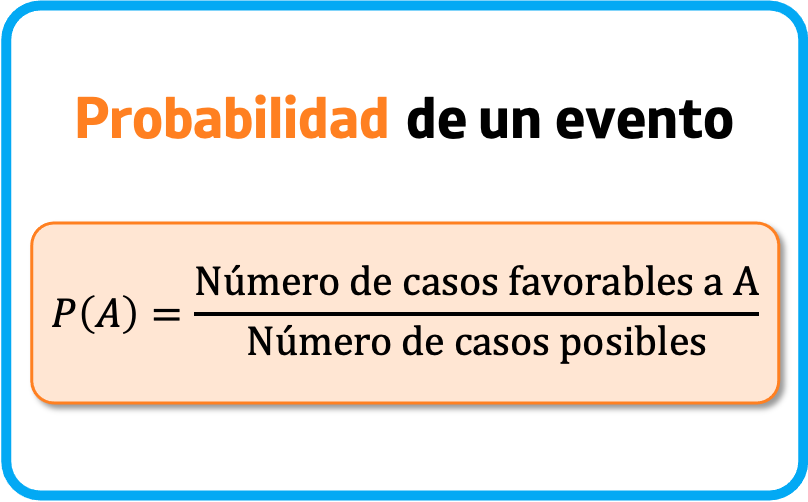

In [5]:

# 1. Contar casos favorables (donde TARGET es 1)
casos_favorables = (df_maestro['TARGET'] == 1).sum()

# 2. Contar el universo total de observaciones (filas totales del dataframe maestro)
casos_totales = len(df_maestro)

# 3. Calcular la probabilidad empírica (Frecuencia Relativa)
probabilidad_accidente = casos_favorables / casos_totales

# 4. Mostrar el resultado formateado de manera elegante para el informe
print("calculo de probabilidad usando formula de arriba")
print(f"Casos Favorables (Con accidente):  {casos_favorables:,}")
print(f"Casos Totales (Universo de estudio): {casos_totales:,}")
print(f"Probabilidad (en valor decimal):    {probabilidad_accidente:.6f}")
print(f"Probabilidad (en porcentaje):       {probabilidad_accidente * 100:.2f}%")
print("-" * 45)

print(f"Entonces, la probabilidad marginal de que ocurra al menos un accidente en un barrio 'B'")
print(f"a una hora 'h' cualquiera en Medellín es del {probabilidad_accidente * 100:.2f}%.")

calculo de probabilidad usando formula de arriba
Casos Favorables (Con accidente):  120,475
Casos Totales (Universo de estudio): 7,991,780
Probabilidad (en valor decimal):    0.015075
Probabilidad (en porcentaje):       1.51%
---------------------------------------------
Entonces, la probabilidad marginal de que ocurra al menos un accidente en un barrio 'B'
a una hora 'h' cualquiera en Medellín es del 1.51%.


## Construcción de la variable objetivo (punto 3)

### 1. Definición de la unidad de análisis
* **Resolución Geográfica:** se dividieron los datos por barrio
* **Resolución Temporal:** la columna `TW se dividió por horas.
* **Cada fila de nuestra base de datos representa un bloque de una hora en un barrio específico de la ciudad (por ejemplo: Belén a las 5:00 p.m. del 10 de octubre). Esa es nuestra unidad de medida para predecir si hay o no un accidente

### 2. Construcción de los Casos Negativos (Parejas sin accidente)
Ya que solo se registran los datos si hubo accidentes (con un 1), cuando no hay accidentes decidimos usar la tabla clima para rellenar todos los momentox "tranqulos" ya que esa tabla tenia todas las fechas y las horas. entonces, en las fechas que hay un caso de accidentalidad se asigna un 1 al clima, de lo contrario (no hay conincidencias) se asigna 0.

### 3. Proporción de la Clase Positiva y Motivación del Proyecto
Los resultados obtenidos tras juntar ambos data sets arrojaron la siguiente distribución:

| Clase Target | Significado | Cantidad de Observaciones | Proporción (%) |
| :--- | :--- | :--- | :--- |
| **Clase 0** | Sin Accidente | 7,871,305 | 98.49% |
| **Clase 1** | Con Accidente | 120,475 | **1.51%** |

Lo cual se muestra como un modelo DESBALANCEADO, ya que tiene muy pocos casos positivos y muchos negativos, por lo que mas adelante debera usarse un metodo de balance de datos para arreglar este problema. 


## Preparación de Features Cíclicas (Rol: Ingeniero de Datos)

### Transformación de la Hora (0–23) con Seno y Coseno

La hora del día **no puede tratarse como un número lineal** (0 a 23) porque los modelos interpretarían que la hora 23 y la hora 0 están a 23 unidades de distancia, cuando en realidad son horas consecutivas. Al representar la hora sobre un círculo mediante las funciones trigonométricas **seno y coseno**, se preserva la continuidad cíclica: las 11:00 p.m. (hora 23) y las 12:00 a.m. (hora 0) quedan a distancia mínima en el espacio bidimensional resultante $(\sin, \cos)$, permitiendo que el modelo aprenda correctamente los patrones de accidentalidad asociados a la transición de medianoche.

In [6]:
import numpy as np

# Punto 4.4 - Transformación de Características Cíclicas (Hora)

# Extraer la hora numérica (0-23) desde la columna datetime TW si no existe ya
if 'Hora_num' not in df_maestro.columns:
    df_maestro['Hora_num'] = df_maestro['TW'].dt.hour

# Definimos el período total del ciclo (24 horas en un día)
p_hora = 24

# Creación de la componente Seno
df_maestro['hora_sin'] = np.sin(2 * np.pi * df_maestro['Hora_num'] / p_hora)

# Creación de la componente Coseno
df_maestro['hora_cos'] = np.cos(2 * np.pi * df_maestro['Hora_num'] / p_hora)

# Verificar visualmente la transformación de las nuevas columnas
print("Transformación cíclica de la hora (muestra de valores únicos):")
print(df_maestro[['Hora_num', 'hora_sin', 'hora_cos']].drop_duplicates().sort_values('Hora_num').head(5))
print(f"\nNuevas columnas añadidas: 'hora_sin' y 'hora_cos'")
print(f"Shape del DataFrame maestro actualizado: {df_maestro.shape}")

Transformación cíclica de la hora (muestra de valores únicos):
   Hora_num  hora_sin  hora_cos
0         0  0.000000  1.000000
1         1  0.258819  0.965926
2         2  0.500000  0.866025
3         3  0.707107  0.707107
4         4  0.866025  0.500000

Nuevas columnas añadidas: 'hora_sin' y 'hora_cos'
Shape del DataFrame maestro actualizado: (7991780, 19)


---


# EDA 4.1: accidentalidad vial y clima

Este notebook desarrolla exclusivamente el punto **4.1 Analisis exploratorio (EDA)** del taller.

El plan de trabajo seguido esta documentado en `EDA_4_1_SPEC.md`.

**Criterio metodologico**
- `raw_accidentes` se usa para contar accidentes reales en el tiempo y en el espacio.
- `accidentes + clima` se usa para estudiar la **accidentalidad binaria** por `(barrio, hora)`.
- Se priorizan visualizaciones que justifiquen decisiones de modelado posteriores.
- Esta version agrega tasas espaciales, una visual geografica real y cruces mas ricos entre tiempo y espacio.


In [7]:

from pathlib import Path
import sqlite3
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', context='talk')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

PROJECT_ROOT = Path.cwd()
DB_PATH = PROJECT_ROOT / 'data_accidentes.sqlite3'
assert DB_PATH.exists(), f'No se encontro la base de datos en {DB_PATH}'

WEEKDAY_ORDER = ['LUNES', 'MARTES', 'MIERCOLES', 'JUEVES', 'VIERNES', 'SABADO', 'DOMINGO']
WEEKDAY_LABELS = {
    'LUNES': 'Lunes',
    'MARTES': 'Martes',
    'MIERCOLES': 'Miercoles',
    'JUEVES': 'Jueves',
    'VIERNES': 'Viernes',
    'SABADO': 'Sabado',
    'DOMINGO': 'Domingo',
}
MONTH_NAMES = {
    1: 'Ene', 2: 'Feb', 3: 'Mar', 4: 'Abr', 5: 'May', 6: 'Jun',
    7: 'Jul', 8: 'Ago', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dic'
}
CLIMATE_LABELS = {
    'temperature': 'Temperatura',
    'precipIntensity': 'Intensidad lluvia',
    'precipProbability': 'Probabilidad lluvia',
    'windSpeed': 'Velocidad viento',
}
ACCIDENT_LABELS = {0: 'Sin accidente', 1: 'Con accidente'}


def normalize_text(series: pd.Series, lower: bool = False) -> pd.Series:
    cleaned = series.astype(str).str.strip()
    return cleaned.str.lower() if lower else cleaned


In [8]:

with sqlite3.connect(DB_PATH) as conn:
    scope_df = pd.read_sql_query(
        """
        SELECT 'raw_accidentes' AS tabla,
               COUNT(*) AS filas,
               COUNT(DISTINCT BARRIO) AS barrios,
               COUNT(DISTINCT COMUNA) AS comunas,
               MIN(TW) AS inicio,
               MAX(TW) AS fin
        FROM raw_accidentes
        UNION ALL
        SELECT 'accidentes' AS tabla,
               COUNT(*) AS filas,
               COUNT(DISTINCT BARRIO) AS barrios,
               NULL AS comunas,
               MIN(TW) AS inicio,
               MAX(TW) AS fin
        FROM accidentes
        UNION ALL
        SELECT 'clima' AS tabla,
               COUNT(*) AS filas,
               COUNT(DISTINCT BARRIO) AS barrios,
               NULL AS comunas,
               MIN(TW) AS inicio,
               MAX(TW) AS fin
        FROM clima
        """,
        conn,
    )

    raw_accidentes = pd.read_sql_query(
        'SELECT TW, BARRIO, COMUNA, Dia_sem, Mes, Hora_num AS Hora, Lat, Lon FROM raw_accidentes',
        conn,
    )
    accident_keys = pd.read_sql_query('SELECT TW, BARRIO FROM accidentes', conn)
    clima_barrios = pd.read_sql_query('SELECT DISTINCT BARRIO FROM clima', conn)
    clima_pairs_barrio = pd.read_sql_query('SELECT BARRIO, COUNT(*) AS total_pairs FROM clima GROUP BY BARRIO', conn)

raw_accidentes['TW'] = pd.to_datetime(raw_accidentes['TW'])
raw_accidentes['BARRIO'] = normalize_text(raw_accidentes['BARRIO'], lower=True)
raw_accidentes['COMUNA'] = normalize_text(raw_accidentes['COMUNA']).replace({'None': 'Sin dato', 'nan': 'Sin dato'})
raw_accidentes['Dia_sem'] = normalize_text(raw_accidentes['Dia_sem']).str.upper()
accident_keys['BARRIO'] = normalize_text(accident_keys['BARRIO'], lower=True)
clima_barrios['BARRIO'] = normalize_text(clima_barrios['BARRIO'], lower=True)
clima_pairs_barrio['BARRIO'] = normalize_text(clima_pairs_barrio['BARRIO'], lower=True)

barrios_sin_clima = sorted(set(accident_keys['BARRIO']) - set(clima_barrios['BARRIO']))
positivos_fuera_cobertura = int(accident_keys['BARRIO'].isin(barrios_sin_clima).sum())

scope_summary = pd.DataFrame({
    'metrica': ['Periodo', 'Accidentes reales', 'Positivos barrio-hora', 'Pares barrio-hora en clima', 'Barrios sin clima'],
    'valor': [
        f"{scope_df['inicio'].iloc[0][:10]} a {scope_df['fin'].iloc[0][:10]}",
        f"{len(raw_accidentes):,}",
        f"{len(accident_keys):,}",
        f"{int(scope_df.loc[scope_df['tabla'] == 'clima', 'filas'].iloc[0]):,}",
        f"{len(barrios_sin_clima)} ({positivos_fuera_cobertura} positivos)"
    ]
})

display(scope_df)
display(scope_summary)
display(Markdown(
    f"""
**Resumen inicial**

- El periodo cubre de **{scope_df['inicio'].iloc[0][:10]}** a **{scope_df['fin'].iloc[0][:10]}**.
- `raw_accidentes` tiene el conteo real de accidentes: **{len(raw_accidentes):,}** registros.
- `accidentes` resume la ocurrencia de al menos un accidente por `(barrio, hora)`: **{len(accident_keys):,}** positivos observados.
- `clima` define el conjunto modelable con **{int(scope_df.loc[scope_df['tabla'] == 'clima', 'filas'].iloc[0]):,}** pares `(barrio, hora)`.
- Hay **{positivos_fuera_cobertura}** positivos fuera de la cobertura climatica, asociados a estos barrios sin cobertura en `clima`: **{', '.join(barrios_sin_clima)}**.
"""
))


,tabla,filas,barrios,comunas,inicio,fin
0,raw_accidentes,125122,322,81.0000,2017-01-01 00:00:00,2019-12-31 23:00:00
1,accidentes,120587,322,NaN,2017-01-01 00:00:00,2019-12-31 23:00:00
2,clima,7991780,319,NaN,2017-01-01 00:00:00,2019-12-31 23:00:00


,metrica,valor
0,Periodo,2017-01-01 a 2019-12-31
1,Accidentes reales,"125,122"
2,Positivos barrio-hora,"120,587"
3,Pares barrio-hora en clima,"7,991,780"
4,Barrios sin clima,3 (4 positivos)



**Resumen inicial**

- El periodo cubre de **2017-01-01** a **2019-12-31**.
- `raw_accidentes` tiene el conteo real de accidentes: **125,122** registros.
- `accidentes` resume la ocurrencia de al menos un accidente por `(barrio, hora)`: **120,587** positivos observados.
- `clima` define el conjunto modelable con **7,991,780** pares `(barrio, hora)`.
- Hay **4** positivos fuera de la cobertura climatica, asociados a estos barrios sin cobertura en `clima`: **elastillero, suburbanoaguasfrias, yarumalito**.


## 1. Distribucion temporal

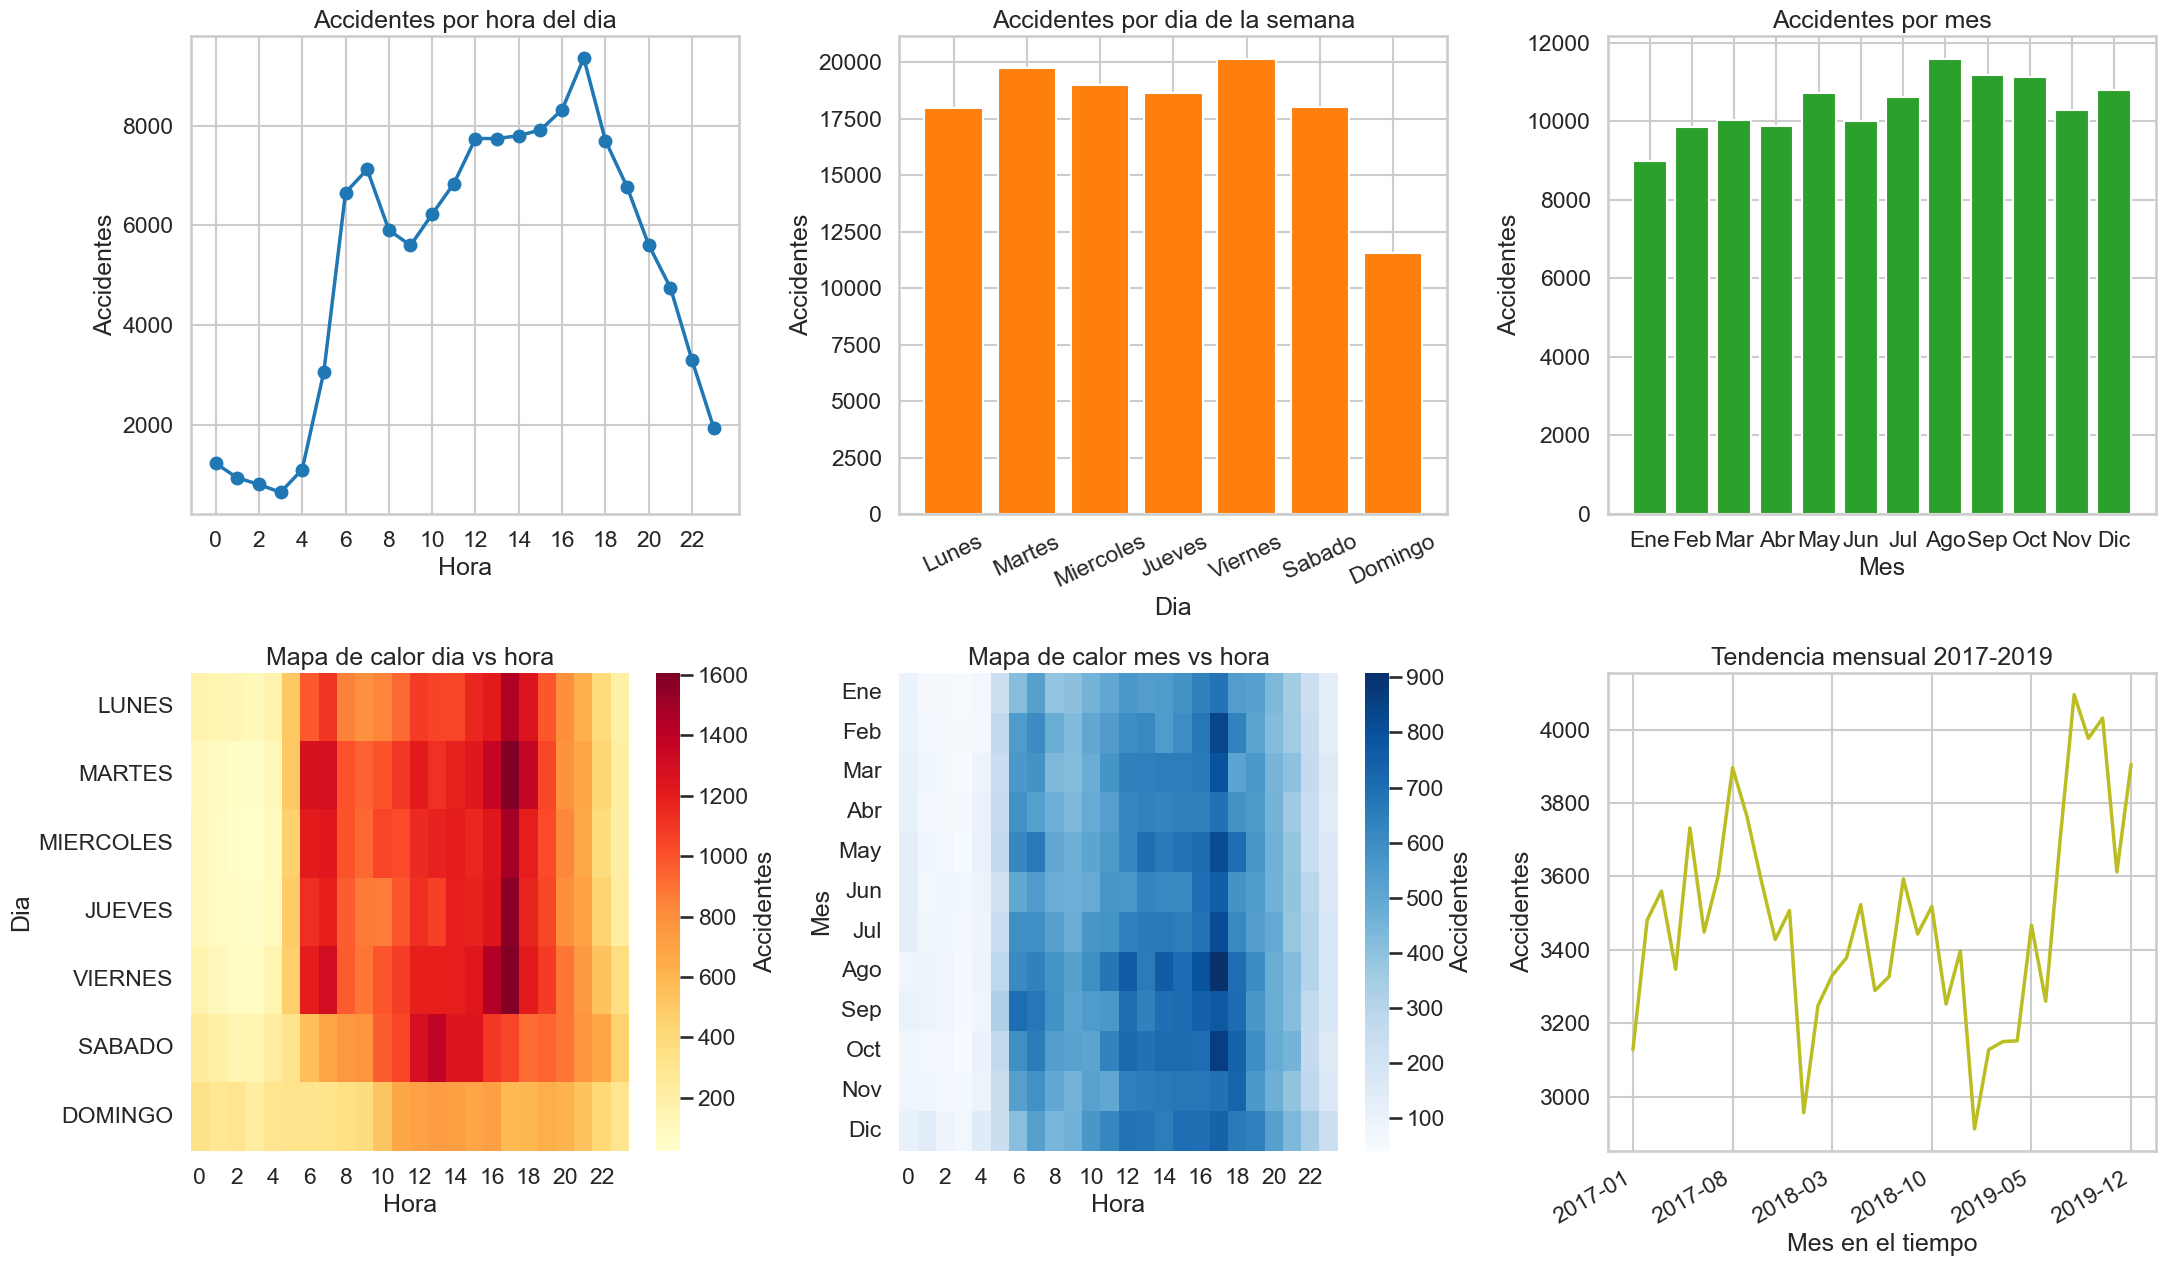

,metrica,valor
0,Hora pico,"17:00 (9,355)"
1,Dia pico,"Viernes (20,141)"
2,Mes pico,"Ago (11,584)"


In [9]:

hour_counts = raw_accidentes.groupby('Hora').size().sort_index()
weekday_counts = raw_accidentes.groupby('Dia_sem').size().reindex(WEEKDAY_ORDER)
month_counts = raw_accidentes.groupby('Mes').size().reindex(range(1, 13))
heatmap_day_hour = (
    raw_accidentes.pivot_table(index='Dia_sem', columns='Hora', aggfunc='size', fill_value=0)
    .reindex(WEEKDAY_ORDER)
)
heatmap_month_hour = (
    raw_accidentes.pivot_table(index='Mes', columns='Hora', aggfunc='size', fill_value=0)
    .reindex(range(1, 13))
)
monthly_trend = (
    raw_accidentes.assign(year_month=raw_accidentes['TW'].dt.to_period('M').astype(str))
    .groupby('year_month')
    .size()
)

peak_hour = int(hour_counts.idxmax())
peak_weekday = weekday_counts.idxmax()
peak_month = int(month_counts.idxmax())

fig, axes = plt.subplots(2, 3, figsize=(22, 13))

axes[0, 0].plot(hour_counts.index, hour_counts.values, marker='o', linewidth=2.5, color='#1f77b4')
axes[0, 0].set_title('Accidentes por hora del dia')
axes[0, 0].set_xlabel('Hora')
axes[0, 0].set_ylabel('Accidentes')
axes[0, 0].set_xticks(range(0, 24, 2))

axes[0, 1].bar([WEEKDAY_LABELS[d] for d in weekday_counts.index], weekday_counts.values, color='#ff7f0e')
axes[0, 1].set_title('Accidentes por dia de la semana')
axes[0, 1].set_xlabel('Dia')
axes[0, 1].set_ylabel('Accidentes')
axes[0, 1].tick_params(axis='x', rotation=25)

axes[0, 2].bar([MONTH_NAMES[m] for m in month_counts.index], month_counts.values, color='#2ca02c')
axes[0, 2].set_title('Accidentes por mes')
axes[0, 2].set_xlabel('Mes')
axes[0, 2].set_ylabel('Accidentes')

sns.heatmap(heatmap_day_hour, cmap='YlOrRd', ax=axes[1, 0], cbar_kws={'label': 'Accidentes'})
axes[1, 0].set_title('Mapa de calor dia vs hora')
axes[1, 0].set_xlabel('Hora')
axes[1, 0].set_ylabel('Dia')

sns.heatmap(heatmap_month_hour, cmap='Blues', ax=axes[1, 1], cbar_kws={'label': 'Accidentes'})
axes[1, 1].set_title('Mapa de calor mes vs hora')
axes[1, 1].set_xlabel('Hora')
axes[1, 1].set_ylabel('Mes')
axes[1, 1].set_yticklabels([MONTH_NAMES[m] for m in heatmap_month_hour.index], rotation=0)

axes[1, 2].plot(range(len(monthly_trend)), monthly_trend.values, linewidth=2.5, color='#bcbd22')
axes[1, 2].set_title('Tendencia mensual 2017-2019')
axes[1, 2].set_xlabel('Mes en el tiempo')
axes[1, 2].set_ylabel('Accidentes')
xticks = np.linspace(0, len(monthly_trend) - 1, 6, dtype=int)
axes[1, 2].set_xticks(xticks)
axes[1, 2].set_xticklabels(monthly_trend.index[xticks], rotation=30, ha='right')

plt.tight_layout()
plt.show()

temporal_summary = pd.DataFrame({
    'metrica': ['Hora pico', 'Dia pico', 'Mes pico'],
    'valor': [
        f"{peak_hour:02d}:00 ({int(hour_counts.max()):,})",
        f"{WEEKDAY_LABELS[peak_weekday]} ({int(weekday_counts.max()):,})",
        f"{MONTH_NAMES[peak_month]} ({int(month_counts.max()):,})",
    ]
})

display(temporal_summary)


Analisis temporal:

1.La accidentalidad se concentra en franjas diurnas y de cierre de jornada: el pico aparece a las 17:00.
2.Viernes y Agosto son los cortes temporales con mayor carga.
3.Los mapas de calor sugieren que la hora interactua con el dia y el mes, por lo que conviene conservar variables temporales y sus cruces.

## 2. Distribucion espacial

In [10]:

barrio_counts = raw_accidentes.groupby('BARRIO').size().rename('accidentes_reales').sort_values(ascending=False)
comuna_counts = raw_accidentes.groupby('COMUNA').size().rename('accidentes_reales').sort_values(ascending=False)

barrio_mode_comuna = (
    raw_accidentes.groupby(['BARRIO', 'COMUNA']).size().rename('n').reset_index()
    .sort_values(['BARRIO', 'n', 'COMUNA'], ascending=[True, False, True])
    .drop_duplicates(subset=['BARRIO'])
    [['BARRIO', 'COMUNA']]
)

barrio_coords = raw_accidentes.groupby('BARRIO').agg(Lat=('Lat', 'median'), Lon=('Lon', 'median')).reset_index()
positive_barrio = (
    accident_keys[~accident_keys['BARRIO'].isin(barrios_sin_clima)]
    .groupby('BARRIO')
    .size()
    .rename('positive_pairs')
)

spatial_barrio = (
    clima_pairs_barrio.set_index('BARRIO')
    .join(barrio_counts, how='left')
    .join(positive_barrio, how='left')
    .fillna({'accidentes_reales': 0, 'positive_pairs': 0})
    .reset_index()
    .merge(barrio_mode_comuna, on='BARRIO', how='left')
    .merge(barrio_coords, on='BARRIO', how='left')
)
spatial_barrio['accidentes_reales'] = spatial_barrio['accidentes_reales'].astype(int)
spatial_barrio['positive_pairs'] = spatial_barrio['positive_pairs'].astype(int)
spatial_barrio['rate_pct'] = spatial_barrio['positive_pairs'] / spatial_barrio['total_pairs'] * 100

spatial_comuna = (
    spatial_barrio.groupby('COMUNA', dropna=False)[['accidentes_reales', 'positive_pairs', 'total_pairs']]
    .sum()
    .reset_index()
)
spatial_comuna['rate_pct'] = spatial_comuna['positive_pairs'] / spatial_comuna['total_pairs'] * 100
spatial_comuna = spatial_comuna.sort_values('accidentes_reales', ascending=False)

cum_barrios_pct = barrio_counts.cumsum() / barrio_counts.sum() * 100
cum_comunas_pct = comuna_counts.cumsum() / comuna_counts.sum() * 100
barrios_50 = int(np.searchsorted(cum_barrios_pct.to_numpy(), 50) + 1)
barrios_80 = int(np.searchsorted(cum_barrios_pct.to_numpy(), 80) + 1)
barrios_90 = int(np.searchsorted(cum_barrios_pct.to_numpy(), 90) + 1)
comunas_50 = int(np.searchsorted(cum_comunas_pct.to_numpy(), 50) + 1)
comunas_80 = int(np.searchsorted(cum_comunas_pct.to_numpy(), 80) + 1)
comunas_90 = int(np.searchsorted(cum_comunas_pct.to_numpy(), 90) + 1)

share_table = pd.DataFrame([
    {'grupo': 'Top 10 barrios', 'participacion_pct': barrio_counts.head(10).sum() / barrio_counts.sum() * 100},
    {'grupo': 'Top 25 barrios', 'participacion_pct': barrio_counts.head(25).sum() / barrio_counts.sum() * 100},
    {'grupo': 'Top 50 barrios', 'participacion_pct': barrio_counts.head(50).sum() / barrio_counts.sum() * 100},
    {'grupo': 'Top 10 comunas', 'participacion_pct': comuna_counts.head(10).sum() / comuna_counts.sum() * 100},
    {'grupo': 'Top 15 comunas', 'participacion_pct': comuna_counts.head(15).sum() / comuna_counts.sum() * 100},
])

map_df = spatial_barrio.dropna(subset=['Lat', 'Lon']).copy()
map_df['size'] = 20 + 220 * (map_df['accidentes_reales'] / map_df['accidentes_reales'].max()) ** 0.7

top_comunas = comuna_counts.head(10).index.tolist()
comuna_hour_heatmap = (
    raw_accidentes[raw_accidentes['COMUNA'].isin(top_comunas)]
    .pivot_table(index='COMUNA', columns='Hora', aggfunc='size', fill_value=0)
    .reindex(top_comunas)
    .reindex(columns=range(24), fill_value=0)
)
comuna_hour_profile = comuna_hour_heatmap.div(comuna_hour_heatmap.sum(axis=1), axis=0) * 100
hour_tick_positions = np.arange(0.5, 24.5, 2)
hour_tick_labels = [f'{h:02d}:00' for h in range(0, 24, 2)]


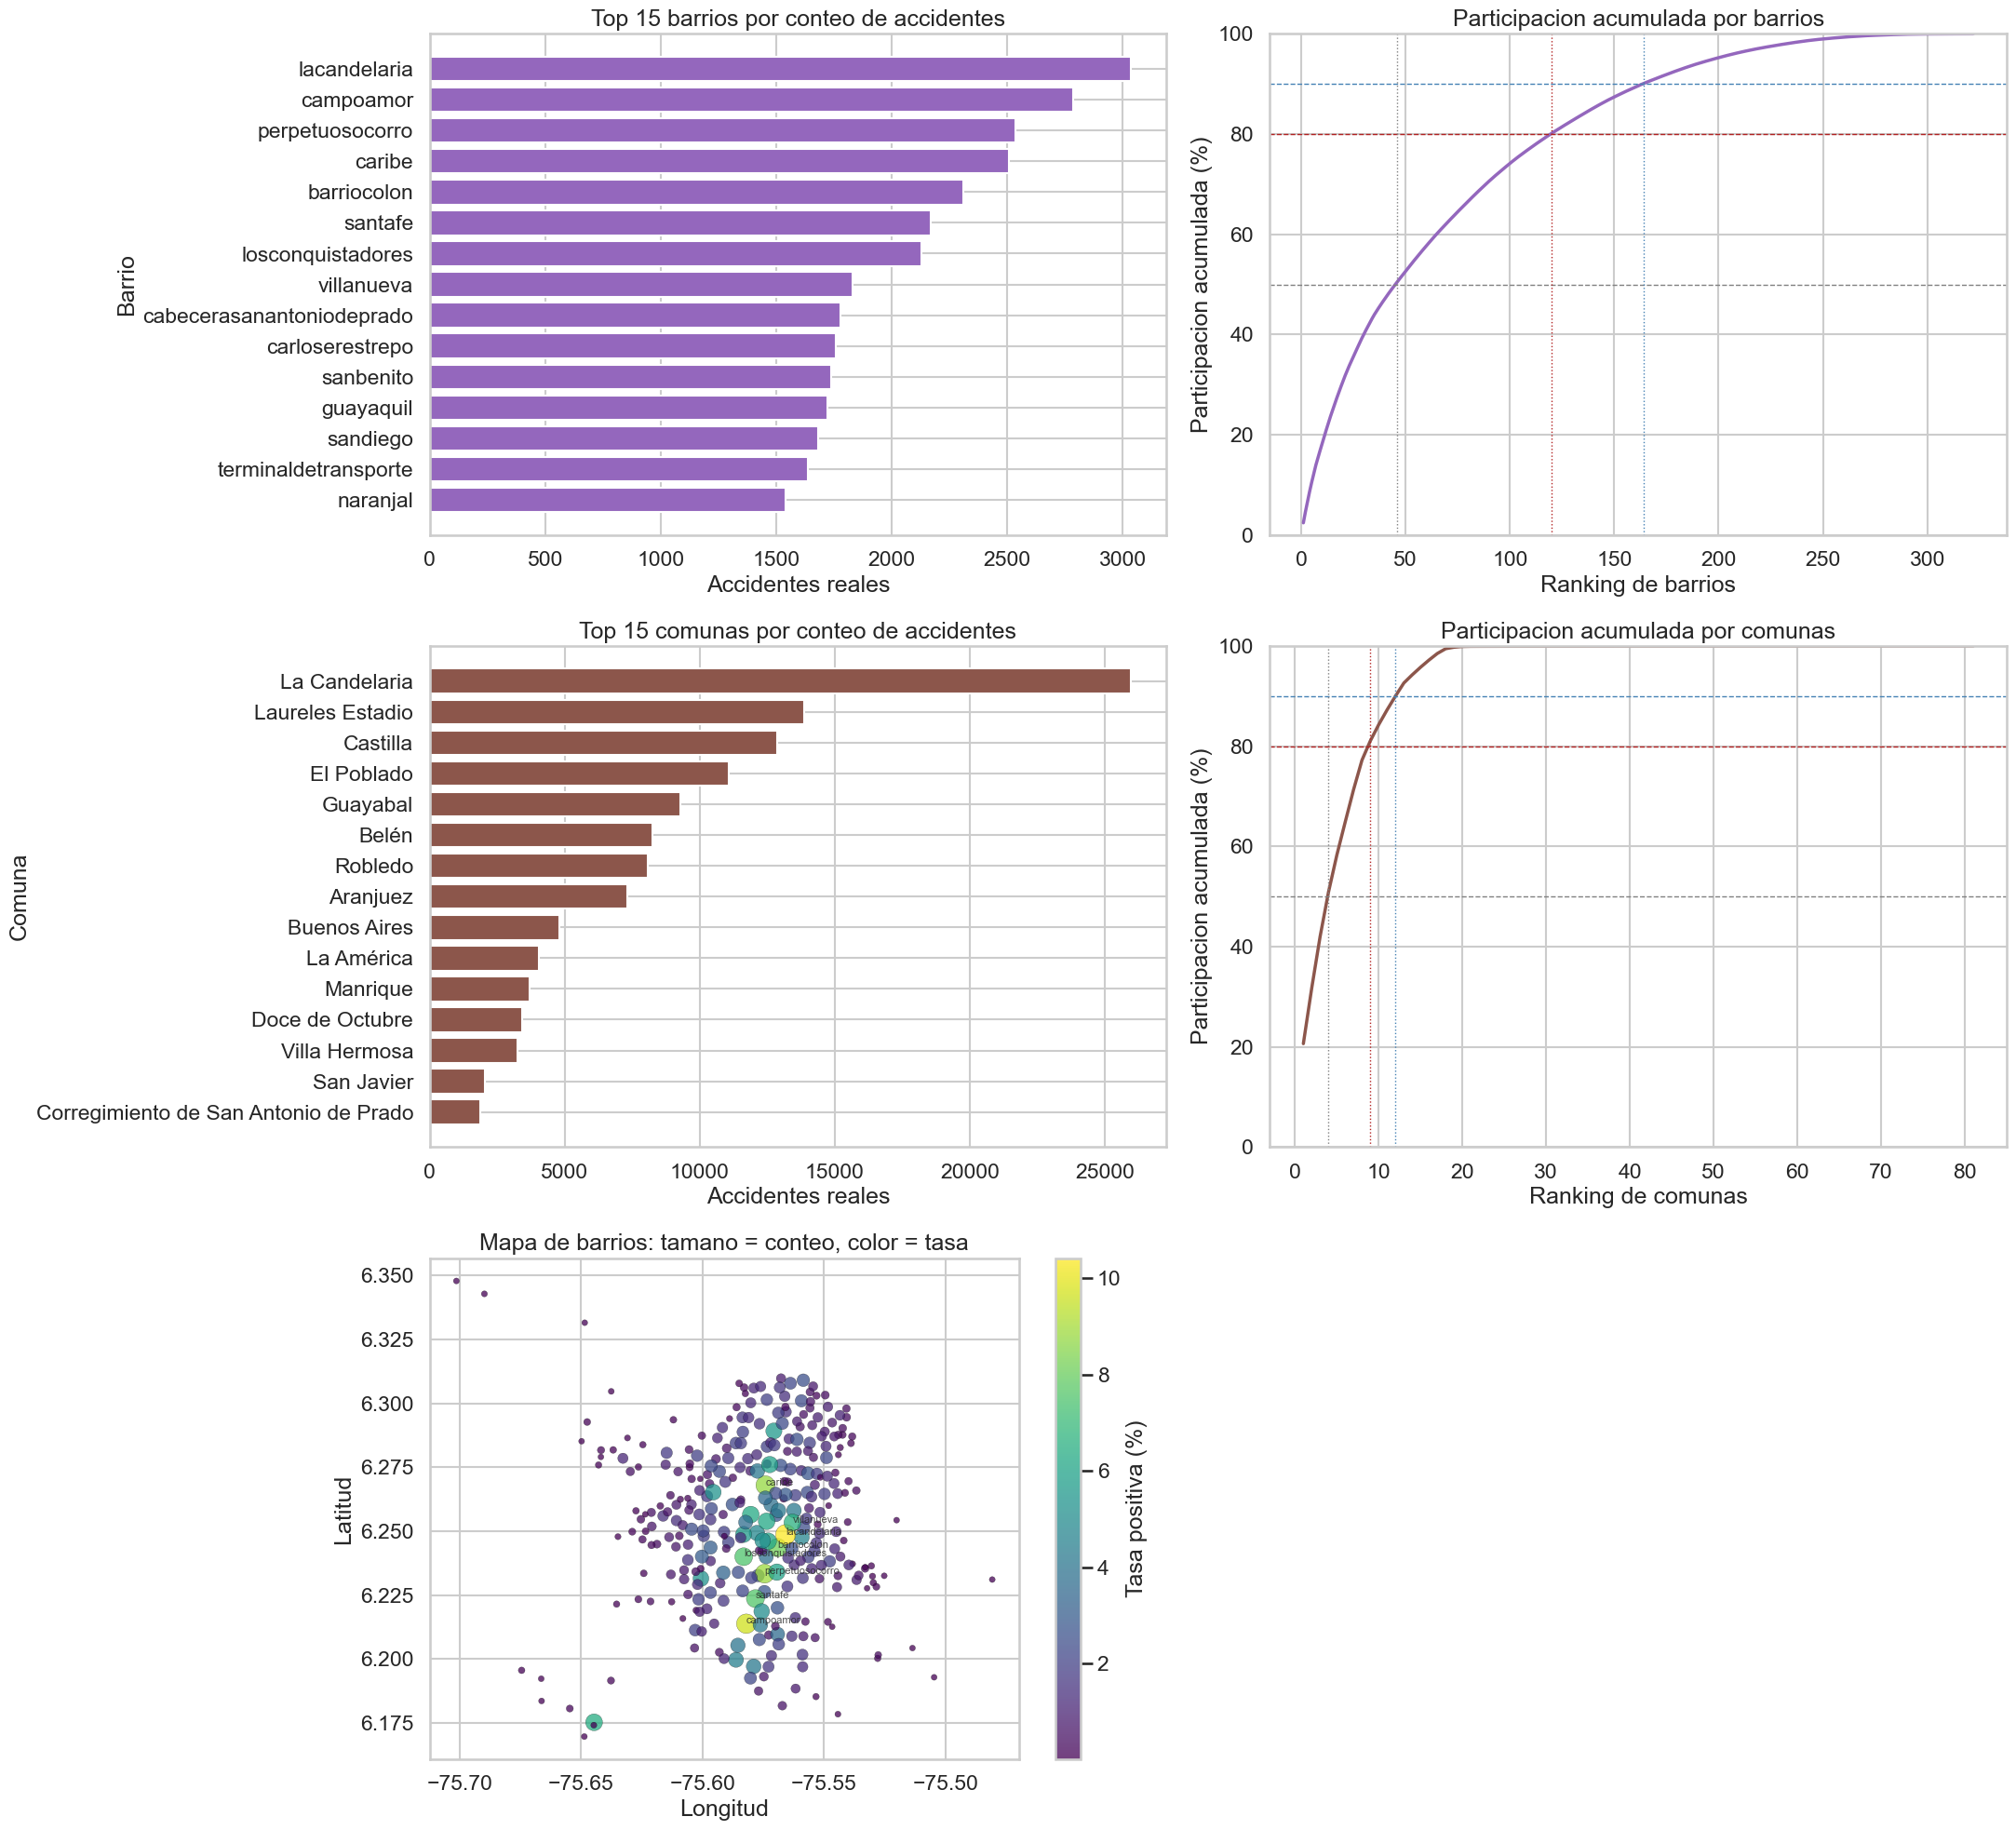

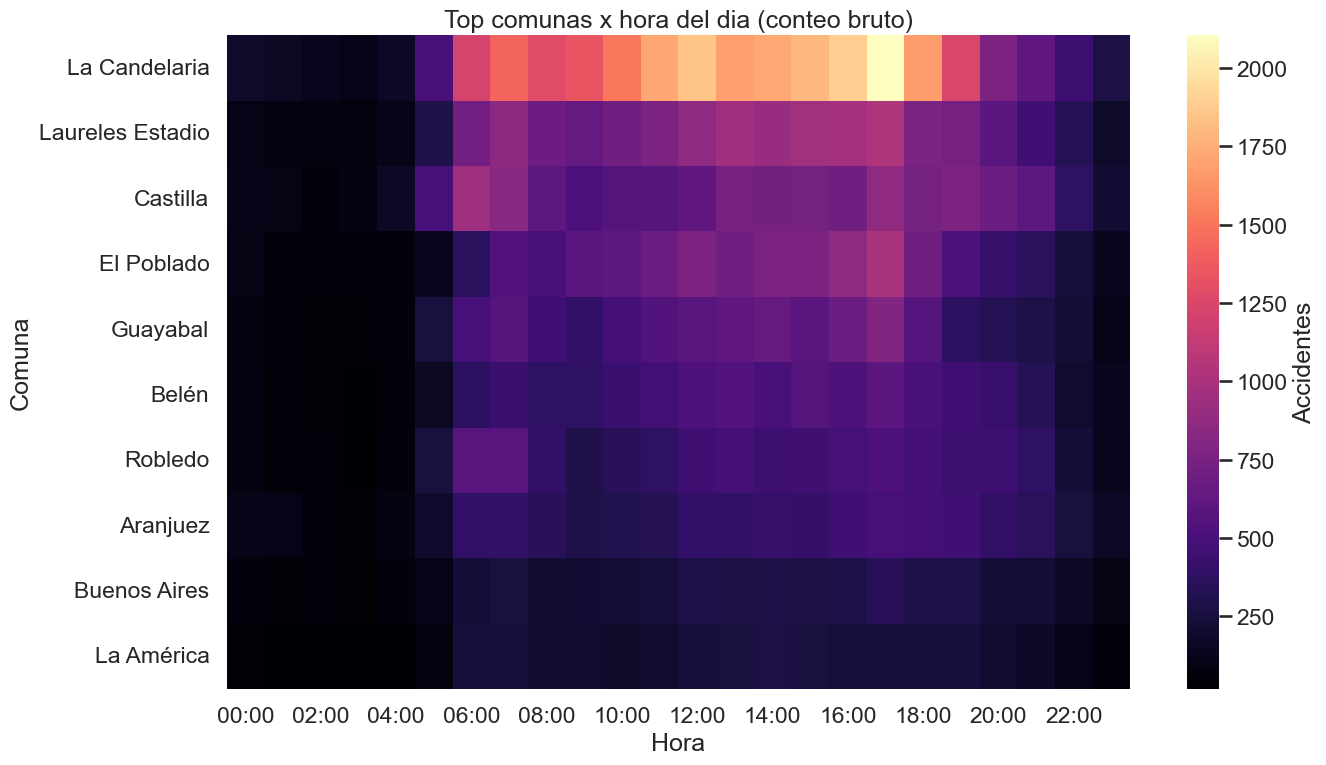

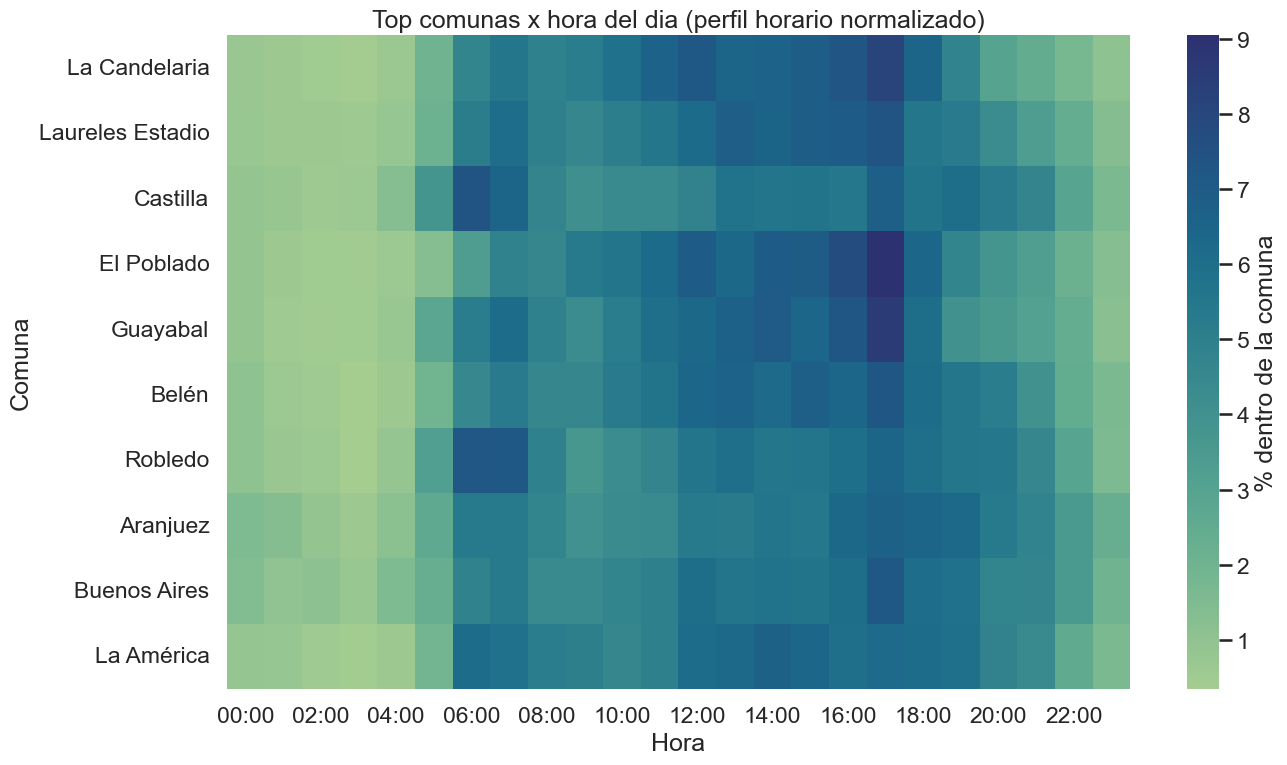

,grupo,participacion_pct
0,Top 10 barrios,18.2500
1,Top 25 barrios,35.6300
2,Top 50 barrios,52.6400
3,Top 10 comunas,84.3100
4,Top 15 comunas,95.7700


,BARRIO,COMUNA,positive_pairs,total_pairs,tasa_pct
135,lacandelaria,La Candelaria,2734,26260,10.4113
54,campoamor,Guayabal,2533,26260,9.6458
230,perpetuosocorro,La Candelaria,2320,26260,8.8347
57,caribe,Castilla,2297,26260,8.7471
25,barriocolon,La Candelaria,2139,26260,8.1455
262,santafe,Guayabal,1994,26260,7.5933
191,losconquistadores,Laureles Estadio,1973,26260,7.5133
314,villanueva,La Candelaria,1722,26260,6.5575
48,cabecerasanantoniodeprado,Corregimiento de San Antonio de Prado,1686,26260,6.4204
58,carloserestrepo,Laureles Estadio,1652,26260,6.2909


,COMUNA,positive_pairs,total_pairs,tasa_pct
18,La Candelaria,24435,525200,4.6525
15,Guayabal,8720,236340,3.6896
20,Laureles Estadio,13288,446420,2.9766
7,Castilla,12300,472680,2.6022
14,El Poblado,10756,577720,1.8618
1,Aranjuez,7195,446420,1.6117
2,Belén,8042,577720,1.3920
23,Robledo,7934,630240,1.2589
17,La América,3992,341380,1.1694
9,Corregimiento de San Antonio de Prado,1799,157580,1.1416


In [11]:

fig, axes = plt.subplots(3, 2, figsize=(22, 20))

axes[0, 0].barh(barrio_counts.head(15).index[::-1], barrio_counts.head(15).values[::-1], color='#9467bd')
axes[0, 0].set_title('Top 15 barrios por conteo de accidentes')
axes[0, 0].set_xlabel('Accidentes reales')
axes[0, 0].set_ylabel('Barrio')

axes[0, 1].plot(range(1, len(cum_barrios_pct) + 1), cum_barrios_pct.values, color='#9467bd', linewidth=2.5)
axes[0, 1].axhline(50, color='gray', linestyle='--', linewidth=1)
axes[0, 1].axhline(80, color='firebrick', linestyle='--', linewidth=1)
axes[0, 1].axhline(90, color='steelblue', linestyle='--', linewidth=1)
axes[0, 1].axvline(barrios_50, color='gray', linestyle=':', linewidth=1)
axes[0, 1].axvline(barrios_80, color='firebrick', linestyle=':', linewidth=1)
axes[0, 1].axvline(barrios_90, color='steelblue', linestyle=':', linewidth=1)
axes[0, 1].set_title('Participacion acumulada por barrios')
axes[0, 1].set_xlabel('Ranking de barrios')
axes[0, 1].set_ylabel('Participacion acumulada (%)')
axes[0, 1].set_ylim(0, 100)

axes[1, 0].barh(spatial_comuna.head(15)['COMUNA'][::-1], spatial_comuna.head(15)['accidentes_reales'][::-1], color='#8c564b')
axes[1, 0].set_title('Top 15 comunas por conteo de accidentes')
axes[1, 0].set_xlabel('Accidentes reales')
axes[1, 0].set_ylabel('Comuna')

axes[1, 1].plot(range(1, len(cum_comunas_pct) + 1), cum_comunas_pct.values, color='#8c564b', linewidth=2.5)
axes[1, 1].axhline(50, color='gray', linestyle='--', linewidth=1)
axes[1, 1].axhline(80, color='firebrick', linestyle='--', linewidth=1)
axes[1, 1].axhline(90, color='steelblue', linestyle='--', linewidth=1)
axes[1, 1].axvline(comunas_50, color='gray', linestyle=':', linewidth=1)
axes[1, 1].axvline(comunas_80, color='firebrick', linestyle=':', linewidth=1)
axes[1, 1].axvline(comunas_90, color='steelblue', linestyle=':', linewidth=1)
axes[1, 1].set_title('Participacion acumulada por comunas')
axes[1, 1].set_xlabel('Ranking de comunas')
axes[1, 1].set_ylabel('Participacion acumulada (%)')
axes[1, 1].set_ylim(0, 100)

scatter = axes[2, 0].scatter(
    map_df['Lon'],
    map_df['Lat'],
    s=map_df['size'],
    c=map_df['rate_pct'],
    cmap='viridis',
    alpha=0.75,
    edgecolor='black',
    linewidth=0.2,
)
axes[2, 0].set_title('Mapa de barrios: tamano = conteo, color = tasa')
axes[2, 0].set_xlabel('Longitud')
axes[2, 0].set_ylabel('Latitud')
plt.colorbar(scatter, ax=axes[2, 0], label='Tasa positiva (%)')
for _, row in map_df.nlargest(8, 'accidentes_reales').iterrows():
    axes[2, 0].annotate(row['BARRIO'], (row['Lon'], row['Lat']), fontsize=8, alpha=0.8)

axes[2, 1].axis('off')

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(comuna_hour_heatmap, cmap='magma', ax=ax, cbar_kws={'label': 'Accidentes'})
ax.set_title('Top comunas x hora del dia (conteo bruto)')
ax.set_xlabel('Hora')
ax.set_ylabel('Comuna')
ax.set_xticks(hour_tick_positions)
ax.set_xticklabels(hour_tick_labels, rotation=0)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(comuna_hour_profile, cmap='crest', ax=ax, cbar_kws={'label': '% dentro de la comuna'})
ax.set_title('Top comunas x hora del dia (perfil horario normalizado)')
ax.set_xlabel('Hora')
ax.set_ylabel('Comuna')
ax.set_xticks(hour_tick_positions)
ax.set_xticklabels(hour_tick_labels, rotation=0)
plt.tight_layout()
plt.show()

display(share_table.round(2))
display(
    spatial_barrio.sort_values('rate_pct', ascending=False)[['BARRIO', 'COMUNA', 'positive_pairs', 'total_pairs', 'rate_pct']]
    .head(15)
    .rename(columns={'rate_pct': 'tasa_pct'})
    .round({'tasa_pct': 4})
)
display(
    spatial_comuna.sort_values('rate_pct', ascending=False)[['COMUNA', 'positive_pairs', 'total_pairs', 'rate_pct']]
    .head(15)
    .rename(columns={'rate_pct': 'tasa_pct'})
    .round({'tasa_pct': 4})
)


Analisis espacial:
1.La concentracion espacial es fuerte a nivel de comuna y mas gradual a nivel de barrio: el 80% de los accidentes se alcanza con 9 comunas y 120 barrios.
2.El mapa bruto resalta volumen, mientras que el perfil horario normalizado separa ese volumen del comportamiento relativo por hora.
3.Esto sugiere usar variables geograficas en varios niveles y considerar interacciones comuna x hora.

### 2.1 Analisis espacial avanzado

In [12]:

from sklearn.cluster import DBSCAN, KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

hourly_barrio = (
    raw_accidentes.pivot_table(index='BARRIO', columns='Hora', aggfunc='size', fill_value=0)
    .reindex(columns=range(24), fill_value=0)
)
hourly_share_barrio = hourly_barrio.div(hourly_barrio.sum(axis=1), axis=0).fillna(0)

profile_df = spatial_barrio.set_index('BARRIO').copy()
profile_df['night_share'] = hourly_share_barrio[[0, 1, 2, 3, 4, 5]].sum(axis=1)
profile_df['morning_peak_share'] = hourly_share_barrio[[6, 7, 8, 9]].sum(axis=1)
profile_df['evening_peak_share'] = hourly_share_barrio[[16, 17, 18, 19]].sum(axis=1)
profile_df['peak_hour'] = hourly_barrio.idxmax(axis=1)
profile_df['log_accidentes'] = np.log1p(profile_df['accidentes_reales'])

kmeans_feature_cols = ['Lat', 'Lon', 'log_accidentes', 'rate_pct', 'night_share', 'morning_peak_share', 'evening_peak_share']
kmeans_input = profile_df[kmeans_feature_cols].dropna().copy()
scaled_kmeans = StandardScaler().fit_transform(kmeans_input)

silhouette_rows = []
for k in range(3, 7):
    labels = KMeans(n_clusters=k, random_state=42, n_init=20).fit_predict(scaled_kmeans)
    silhouette_rows.append({'k': k, 'silhouette': silhouette_score(scaled_kmeans, labels)})

silhouette_df = pd.DataFrame(silhouette_rows).sort_values('k')
best_k = int(silhouette_df.sort_values('silhouette', ascending=False).iloc[0]['k'])

kmeans_model = KMeans(n_clusters=best_k, random_state=42, n_init=20)
kmeans_input['kmeans_cluster'] = kmeans_model.fit_predict(scaled_kmeans)

profile_cluster_summary = (
    profile_df.join(kmeans_input['kmeans_cluster'])
    .groupby('kmeans_cluster')
    .agg(
        n_barrios=('COMUNA', 'size'),
        accidentes_promedio=('accidentes_reales', 'mean'),
        tasa_promedio_pct=('rate_pct', 'mean'),
        night_share_promedio=('night_share', 'mean'),
        morning_share_promedio=('morning_peak_share', 'mean'),
        evening_share_promedio=('evening_peak_share', 'mean'),
        lat_media=('Lat', 'mean'),
        lon_media=('Lon', 'mean'),
    )
    .round(3)
    .reset_index()
)

spatial_barrio = spatial_barrio.merge(
    kmeans_input[['kmeans_cluster']],
    left_on='BARRIO',
    right_index=True,
    how='left',
)

count_median = spatial_barrio.loc[spatial_barrio['accidentes_reales'] > 0, 'accidentes_reales'].median()
rate_median = spatial_barrio.loc[spatial_barrio['rate_pct'] > 0, 'rate_pct'].median()

spatial_barrio['quadrant'] = np.select(
    [
        (spatial_barrio['accidentes_reales'] >= count_median) & (spatial_barrio['rate_pct'] >= rate_median),
        (spatial_barrio['accidentes_reales'] >= count_median) & (spatial_barrio['rate_pct'] < rate_median),
        (spatial_barrio['accidentes_reales'] < count_median) & (spatial_barrio['rate_pct'] >= rate_median),
    ],
    [
        'Alto conteo / Alta tasa',
        'Alto conteo / Baja tasa',
        'Bajo conteo / Alta tasa',
    ],
    default='Bajo conteo / Baja tasa',
)
quadrant_summary = (
    spatial_barrio.groupby('quadrant')
    .agg(barrios=('BARRIO', 'count'))
    .reset_index()
    .sort_values('barrios', ascending=False)
)

map_cluster_df = spatial_barrio.dropna(subset=['Lat', 'Lon']).copy()
coords_radians = np.radians(map_cluster_df[['Lat', 'Lon']].to_numpy())
dbscan_eps_km = 0.75
dbscan_min_samples = 6
dbscan_model = DBSCAN(
    eps=dbscan_eps_km / 6371.0,
    min_samples=dbscan_min_samples,
    metric='haversine',
)
map_cluster_df['dbscan_cluster'] = dbscan_model.fit_predict(coords_radians)

cluster_sizes = map_cluster_df['dbscan_cluster'].value_counts().rename_axis('dbscan_cluster').reset_index(name='n_barrios')
cluster_sizes['tipo'] = np.where(cluster_sizes['dbscan_cluster'] == -1, 'Ruido', 'Cluster')
cluster_sizes = cluster_sizes.sort_values(['tipo', 'n_barrios'], ascending=[True, False])

dbscan_summary = (
    map_cluster_df.groupby('dbscan_cluster')
    .agg(
        n_barrios=('BARRIO', 'size'),
        accidentes_promedio=('accidentes_reales', 'mean'),
        tasa_promedio_pct=('rate_pct', 'mean'),
        lat_media=('Lat', 'mean'),
        lon_media=('Lon', 'mean'),
    )
    .round(3)
    .reset_index()
)

raw_sample_density = raw_accidentes[['Lon', 'Lat']].dropna().sample(n=min(30000, len(raw_accidentes)), random_state=42)


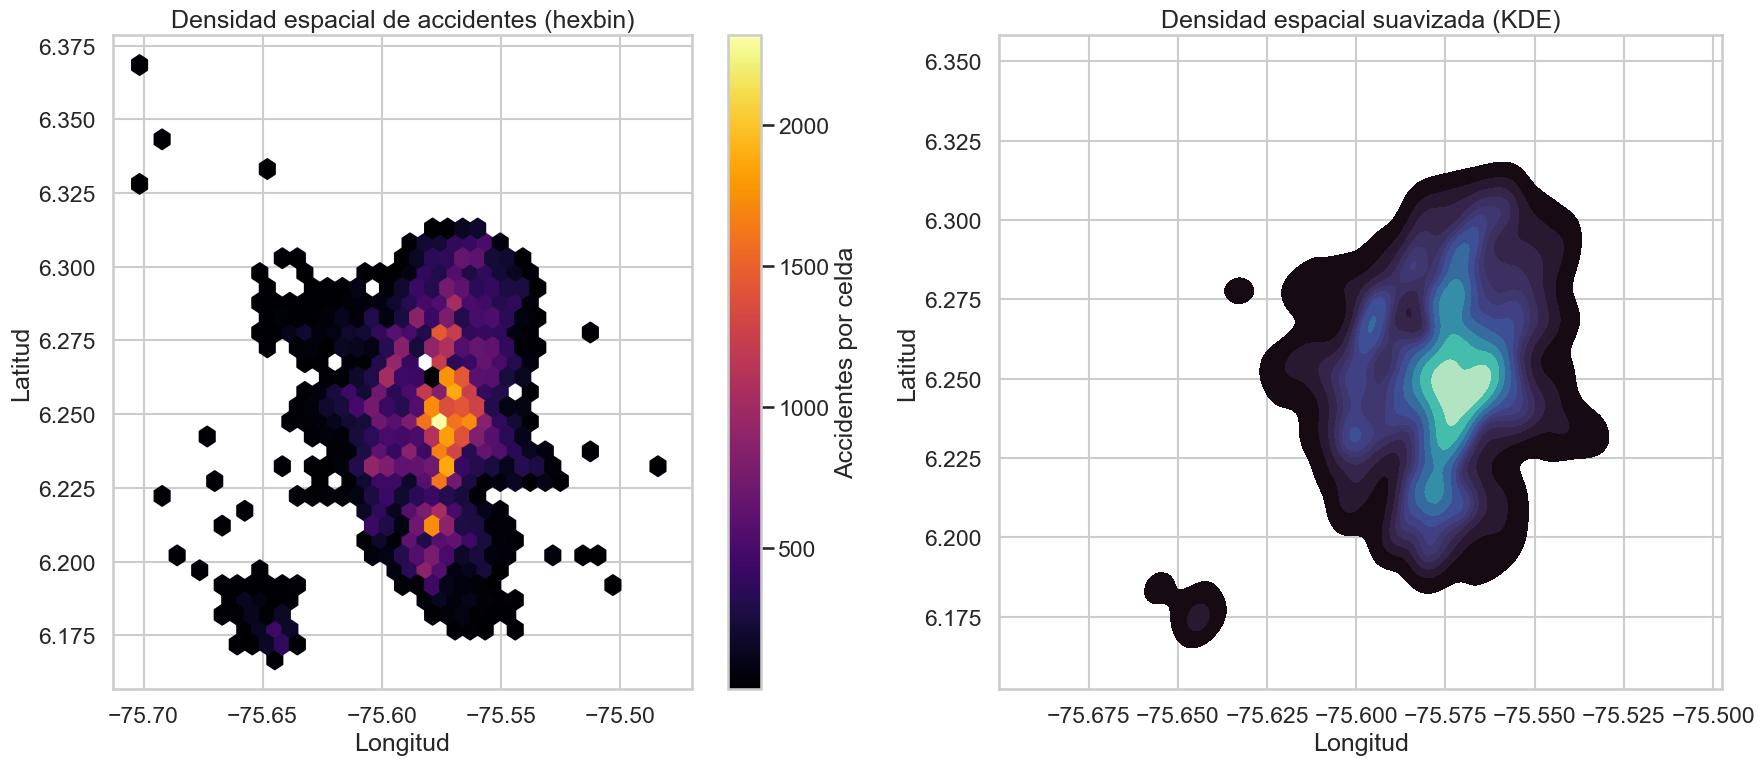

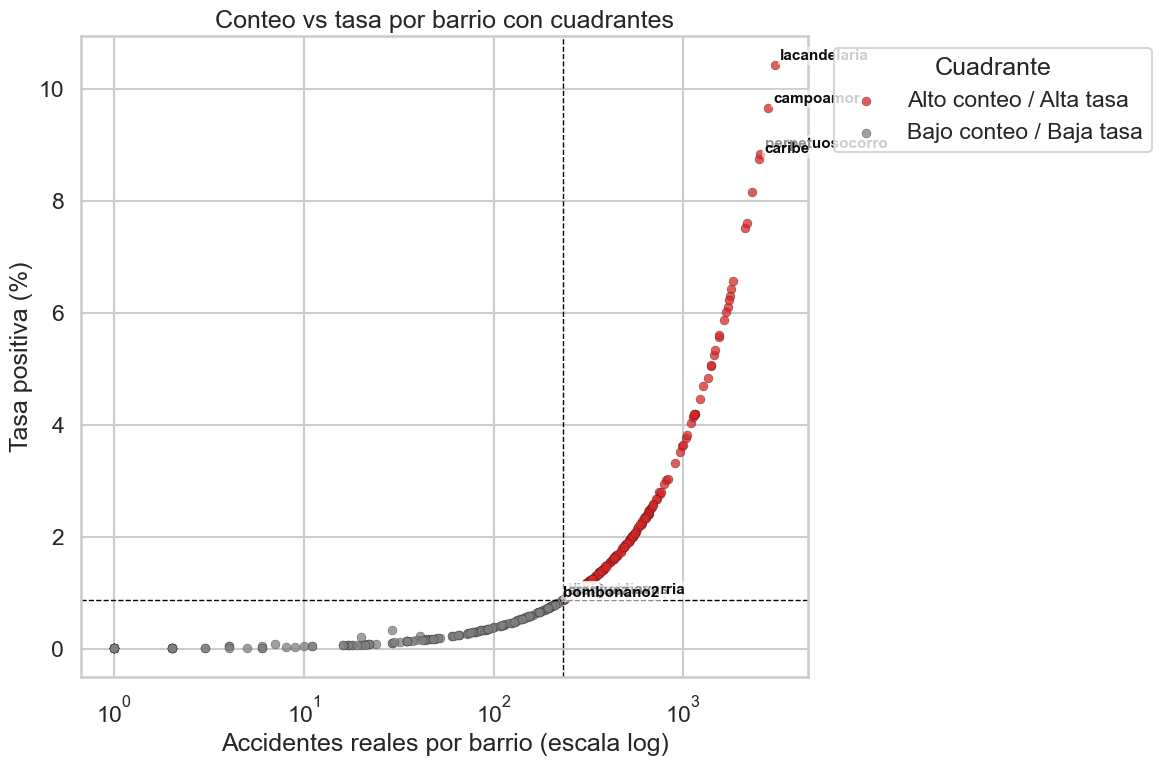

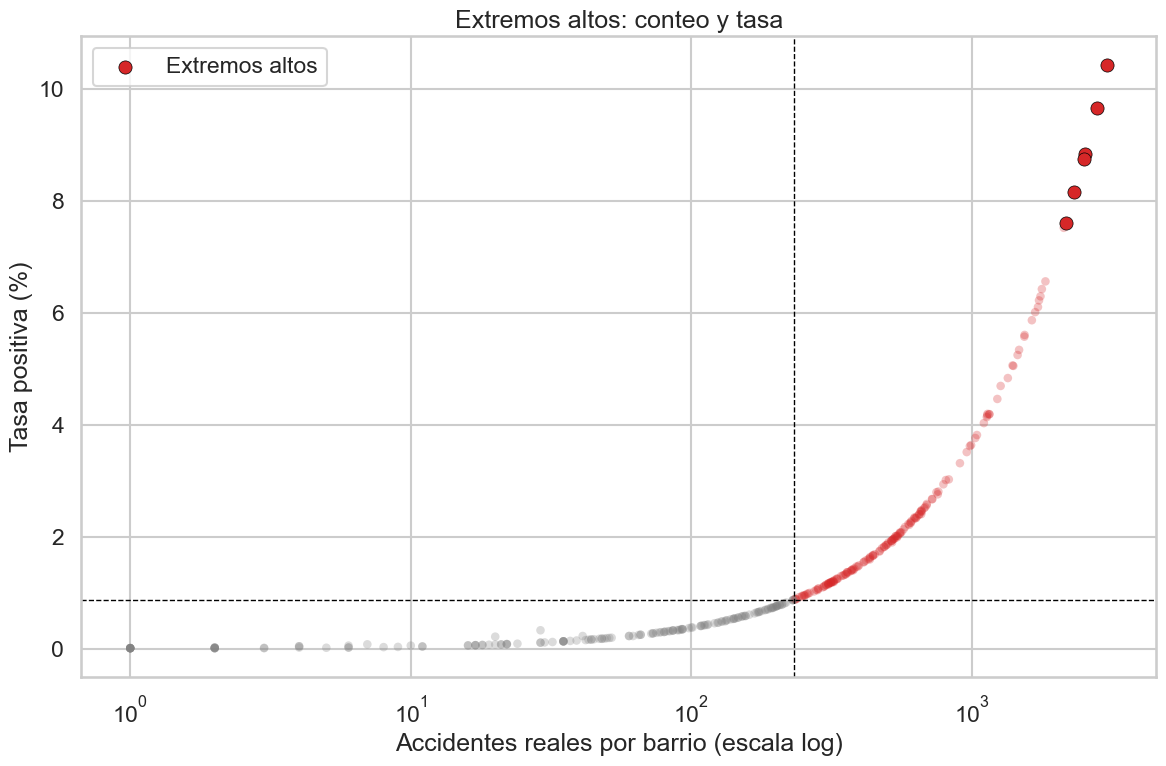

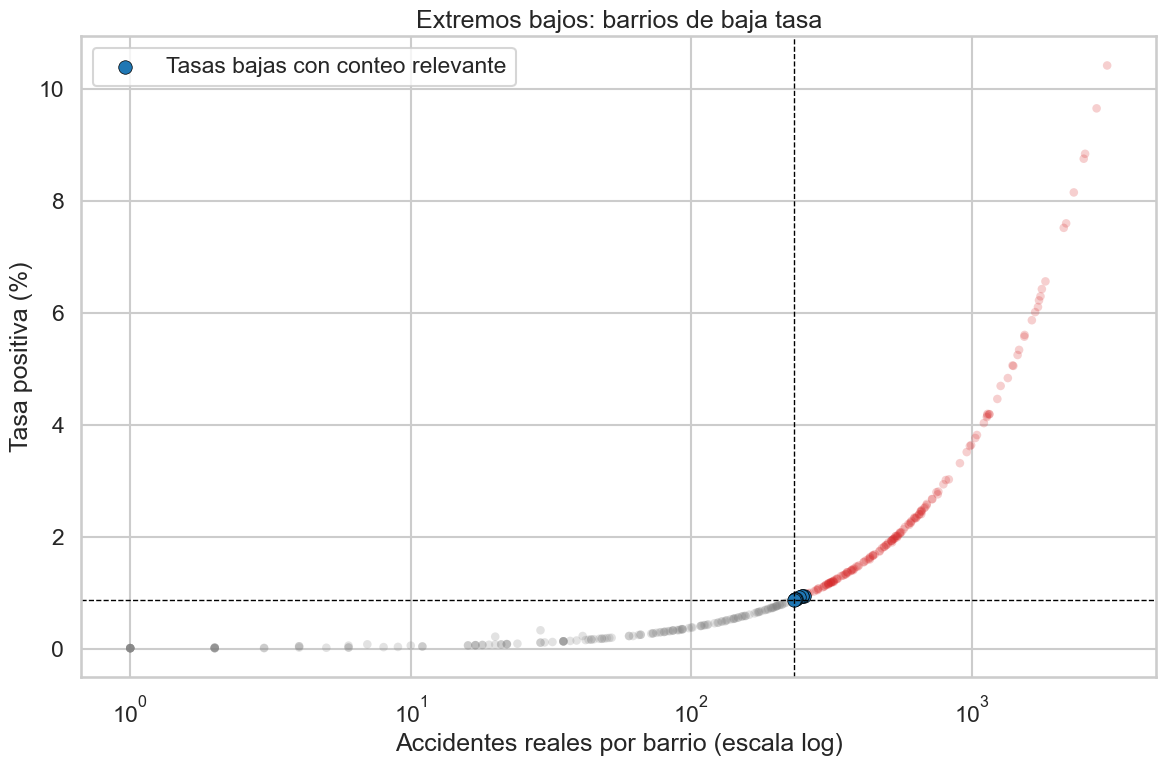

,quadrant,barrios
0,Alto conteo / Alta tasa,160
1,Bajo conteo / Baja tasa,159


,k,silhouette
0,3,0.2517
1,4,0.2085
2,5,0.2212
3,6,0.2261


**Nota:** los graficos de extremos alto/bajo se dejan sin etiquetas para evitar saturacion visual; los nombres completos quedan en las tablas siguientes.

**Representantes por cuadrante**

,quadrant,BARRIO,COMUNA,accidentes_reales,tasa_pct
135,Alto conteo / Alta tasa,lacandelaria,La Candelaria,3037,10.4113
54,Alto conteo / Alta tasa,campoamor,Guayabal,2785,9.6458
230,Alto conteo / Alta tasa,perpetuosocorro,La Candelaria,2534,8.8347
57,Alto conteo / Alta tasa,caribe,Castilla,2506,8.7471
27,Bajo conteo / Baja tasa,barriodejesus,Buenos Aires,231,0.8720
73,Bajo conteo / Baja tasa,diegoechavarria,Belén,230,0.8720
11,Bajo conteo / Baja tasa,aranjuez,Aranjuez,230,0.8644
41,Bajo conteo / Baja tasa,bombonano2,Buenos Aires,218,0.8264


**Barrios con mayor tasa positiva**

,BARRIO,COMUNA,accidentes_reales,tasa_pct
135,lacandelaria,La Candelaria,3037,10.4113
54,campoamor,Guayabal,2785,9.6458
230,perpetuosocorro,La Candelaria,2534,8.8347
57,caribe,Castilla,2506,8.7471
25,barriocolon,La Candelaria,2310,8.1455
262,santafe,Guayabal,2169,7.5933
191,losconquistadores,Laureles Estadio,2127,7.5133
314,villanueva,La Candelaria,1830,6.5575
48,cabecerasanantoniodeprado,Corregimiento de San Antonio de Prado,1777,6.4204
58,carloserestrepo,Laureles Estadio,1757,6.2909


**Barrios con menor tasa positiva entre aquellos con al menos la mediana de accidentes (233)**

,BARRIO,COMUNA,accidentes_reales,tasa_pct
185,losalpes,Belén,233,0.8797
265,santamargarita,Robledo,235,0.8835
180,lomadelosbernal,Belén,237,0.8873
82,eldanubio,La América,235,0.8911
309,villaguadalupe,Popular,242,0.9216
238,popular,Popular,249,0.9368
307,villadelsocorro,Santa Cruz,248,0.9444
117,gerona,Buenos Aires,253,0.9482
87,elnogal-losalmendros,Belén,255,0.9558
155,lamota,Belén,252,0.9558


In [13]:

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

hexbin = axes[0].hexbin(
    raw_accidentes['Lon'],
    raw_accidentes['Lat'],
    gridsize=35,
    cmap='inferno',
    mincnt=1,
)
axes[0].set_title('Densidad espacial de accidentes (hexbin)')
axes[0].set_xlabel('Longitud')
axes[0].set_ylabel('Latitud')
plt.colorbar(hexbin, ax=axes[0], label='Accidentes por celda')

sns.kdeplot(
    data=raw_sample_density,
    x='Lon',
    y='Lat',
    fill=True,
    cmap='mako',
    levels=12,
    thresh=0.03,
    ax=axes[1],
)
axes[1].set_title('Densidad espacial suavizada (KDE)')
axes[1].set_xlabel('Longitud')
axes[1].set_ylabel('Latitud')

plt.tight_layout()
plt.show()

valid_rate_df = spatial_barrio[spatial_barrio['rate_pct'] > 0].copy()
low_rate_focus_df = spatial_barrio[spatial_barrio['accidentes_reales'] >= count_median].copy()

label_high_candidates = pd.concat([
    spatial_barrio.nlargest(6, 'accidentes_reales'),
    valid_rate_df.nlargest(6, 'rate_pct'),
]).drop_duplicates(subset=['BARRIO'])

label_low_candidates = (
    low_rate_focus_df.nsmallest(8, 'rate_pct')
    .sort_values(['accidentes_reales', 'rate_pct'], ascending=[False, True])
)

quadrant_representatives = (
    spatial_barrio[spatial_barrio['accidentes_reales'] > 0]
    .sort_values(['quadrant', 'accidentes_reales', 'rate_pct'], ascending=[True, False, False])
    .groupby('quadrant', group_keys=False)
    .head(4)
    .copy()
)

high_rate_table = (
    valid_rate_df.nlargest(10, 'rate_pct')[['BARRIO', 'COMUNA', 'accidentes_reales', 'rate_pct']]
    .rename(columns={'rate_pct': 'tasa_pct'})
    .round({'tasa_pct': 4})
)

low_rate_table = (
    low_rate_focus_df.nsmallest(10, 'rate_pct')[['BARRIO', 'COMUNA', 'accidentes_reales', 'rate_pct']]
    .rename(columns={'rate_pct': 'tasa_pct'})
    .round({'tasa_pct': 4})
)

quadrant_table = (
    quadrant_representatives[['quadrant', 'BARRIO', 'COMUNA', 'accidentes_reales', 'rate_pct']]
    .rename(columns={'rate_pct': 'tasa_pct'})
    .round({'tasa_pct': 4})
)


def annotate_selected(ax, data, fontsize=11, color='black'):
    for _, row in data.iterrows():
        ax.annotate(
            row['BARRIO'],
            (row['accidentes_reales'], row['rate_pct']),
            xytext=(4, 4),
            textcoords='offset points',
            fontsize=fontsize,
            fontweight='semibold',
            alpha=0.95,
            color=color,
            bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none', alpha=0.55),
        )

quadrant_palette = {
    'Alto conteo / Alta tasa': '#d62728',
    'Alto conteo / Baja tasa': '#ff7f0e',
    'Bajo conteo / Alta tasa': '#1f77b4',
    'Bajo conteo / Baja tasa': '#7f7f7f',
}

fig, ax = plt.subplots(figsize=(12, 8))
for quadrant, subset in spatial_barrio.groupby('quadrant'):
    ax.scatter(
        subset['accidentes_reales'],
        subset['rate_pct'],
        s=42,
        alpha=0.75,
        label=quadrant,
        color=quadrant_palette[quadrant],
        edgecolor='black',
        linewidth=0.2,
    )

ax.axvline(count_median, color='black', linestyle='--', linewidth=1)
ax.axhline(rate_median, color='black', linestyle='--', linewidth=1)
ax.set_xscale('log')
ax.set_title('Conteo vs tasa por barrio con cuadrantes')
ax.set_xlabel('Accidentes reales por barrio (escala log)')
ax.set_ylabel('Tasa positiva (%)')
ax.legend(title='Cuadrante', bbox_to_anchor=(1.02, 1), loc='upper left')
annotate_selected(ax, quadrant_representatives, fontsize=11)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 8))
for quadrant, subset in spatial_barrio.groupby('quadrant'):
    ax.scatter(
        subset['accidentes_reales'],
        subset['rate_pct'],
        s=38,
        alpha=0.28,
        color=quadrant_palette[quadrant],
        edgecolor='none',
    )

ax.scatter(
    label_high_candidates['accidentes_reales'],
    label_high_candidates['rate_pct'],
    s=90,
    color='#d62728',
    edgecolor='black',
    linewidth=0.5,
    label='Extremos altos'
)
ax.axvline(count_median, color='black', linestyle='--', linewidth=1)
ax.axhline(rate_median, color='black', linestyle='--', linewidth=1)
ax.set_xscale('log')
ax.set_title('Extremos altos: conteo y tasa')
ax.set_xlabel('Accidentes reales por barrio (escala log)')
ax.set_ylabel('Tasa positiva (%)')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 8))
for quadrant, subset in spatial_barrio.groupby('quadrant'):
    ax.scatter(
        subset['accidentes_reales'],
        subset['rate_pct'],
        s=38,
        alpha=0.22,
        color=quadrant_palette[quadrant],
        edgecolor='none',
    )

ax.scatter(
    label_low_candidates['accidentes_reales'],
    label_low_candidates['rate_pct'],
    s=95,
    color='#1f77b4',
    edgecolor='black',
    linewidth=0.5,
    label='Tasas bajas con conteo relevante'
)
ax.axvline(count_median, color='black', linestyle='--', linewidth=1)
ax.axhline(rate_median, color='black', linestyle='--', linewidth=1)
ax.set_xscale('log')
ax.set_title('Extremos bajos: barrios de baja tasa')
ax.set_xlabel('Accidentes reales por barrio (escala log)')
ax.set_ylabel('Tasa positiva (%)')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

display(quadrant_summary)
display(silhouette_df.round(4))

display(Markdown('**Nota:** los graficos de extremos alto/bajo se dejan sin etiquetas para evitar saturacion visual; los nombres completos quedan en las tablas siguientes.'))

display(Markdown('**Representantes por cuadrante**'))
display(quadrant_table)

display(Markdown('**Barrios con mayor tasa positiva**'))
display(high_rate_table)

display(Markdown(f'**Barrios con menor tasa positiva entre aquellos con al menos la mediana de accidentes ({count_median:.0f})**'))
display(low_rate_table)


Analisis espacial:
1.La densidad espacial no es uniforme: se observa un corredor central con mayor concentracion de accidentes.
2.El scatter conteo vs tasa separa barrios de alto volumen y barrios de alto riesgo relativo; no siempre coinciden.
3. Hay 160 barrios en el cuadrante de alto conteo / alta tasa, que son candidatos naturales para priorizacion operativa

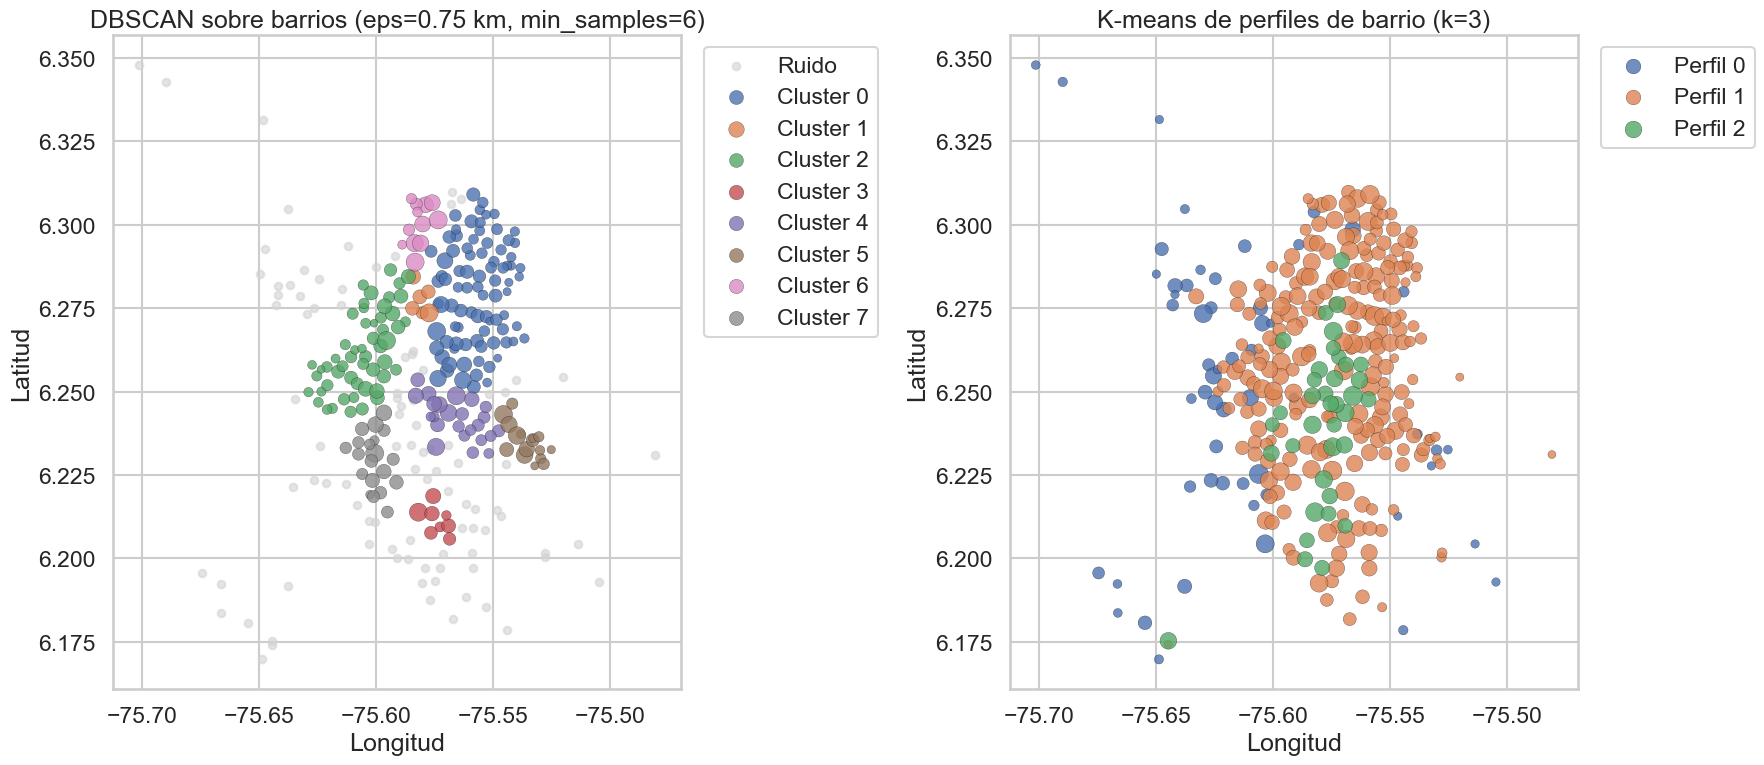

,dbscan_cluster,n_barrios,accidentes_promedio,tasa_promedio_pct,lat_media,lon_media
0,-1,94,325.2870,1.1990,6.2350,-75.5930
1,0,86,416.8600,1.5370,6.2790,-75.5570
2,1,6,478.0000,1.7790,6.2770,-75.5810
3,2,53,257.8490,0.9630,6.2620,-75.6060
4,3,8,966.7500,3.4770,6.2110,-75.5740
5,4,24,926.9170,3.3360,6.2420,-75.5650
6,5,16,94.8750,0.3600,6.2350,-75.5350
7,6,12,254.4170,0.9560,6.3000,-75.5820
8,7,20,380.3000,1.4110,6.2290,-75.6010


,kmeans_cluster,n_barrios,accidentes_promedio,tasa_promedio_pct,night_share_promedio,morning_share_promedio,evening_share_promedio,lat_media,lon_media
0,0,56,29.0890,0.1160,0.0770,0.2490,0.1730,6.2500,-75.6120
1,1,226,295.8190,1.1090,0.0680,0.1880,0.2690,6.2580,-75.5720
2,2,37,"1,530.6490",5.4810,0.0550,0.2040,0.2610,6.2410,-75.5790


,BARRIO,COMUNA,accidentes_reales,rate_pct
0,altavista,Belén,161,0.6093
1,lahondonada,Belén,129,0.4874
2,suburbanolaloma,Corregimiento de San Cristóbal,128,0.4874
3,elsalado,San Javier,86,0.3275
4,barriocristobal,La América,86,0.3275
5,areadeexpansionaltosdecalasanz,Corregimiento de San Cristóbal,73,0.2742
6,plazadeferias,Castilla,73,0.2780
7,elcorazon,San Javier,66,0.2513
8,sevilla,Aranjuez,792,2.9360
9,estacionvilla,La Candelaria,760,2.8065


In [14]:

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

clustered_only = map_cluster_df[map_cluster_df['dbscan_cluster'] != -1].copy()
noise_only = map_cluster_df[map_cluster_df['dbscan_cluster'] == -1].copy()
if not noise_only.empty:
    axes[0].scatter(noise_only['Lon'], noise_only['Lat'], s=30, color='lightgray', alpha=0.6, label='Ruido')
for cluster_id, subset in clustered_only.groupby('dbscan_cluster'):
    axes[0].scatter(
        subset['Lon'],
        subset['Lat'],
        s=30 + 140 * (subset['accidentes_reales'] / subset['accidentes_reales'].max()) ** 0.6,
        alpha=0.8,
        label=f'Cluster {int(cluster_id)}',
        edgecolor='black',
        linewidth=0.2,
    )
axes[0].set_title(f'DBSCAN sobre barrios (eps={dbscan_eps_km:.2f} km, min_samples={dbscan_min_samples})')
axes[0].set_xlabel('Longitud')
axes[0].set_ylabel('Latitud')
axes[0].legend(bbox_to_anchor=(1.02, 1), loc='upper left', ncol=1)

for cluster_id, subset in map_cluster_df.groupby('kmeans_cluster'):
    axes[1].scatter(
        subset['Lon'],
        subset['Lat'],
        s=30 + 160 * (subset['accidentes_reales'] / subset['accidentes_reales'].max()) ** 0.6,
        alpha=0.8,
        label=f'Perfil {int(cluster_id)}',
        edgecolor='black',
        linewidth=0.2,
    )
axes[1].set_title(f'K-means de perfiles de barrio (k={best_k})')
axes[1].set_xlabel('Longitud')
axes[1].set_ylabel('Latitud')
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

display(dbscan_summary.round(3))
display(profile_cluster_summary.round(3))

display(
    spatial_barrio.groupby('kmeans_cluster')[['BARRIO', 'COMUNA', 'accidentes_reales', 'rate_pct']]
    .apply(lambda df: df.sort_values('accidentes_reales', ascending=False).head(8))
    .reset_index(drop=True)
    .round({'rate_pct': 4})
)


Analisis espacial
1.DBSCAN identifica 8 agrupaciones espaciales contiguas y 94 barrios de ruido o periferia.
2.k-means sugiere 3 perfiles de barrio al combinar ubicacion, volumen, tasa y patron horario.
3.Esto respalda que el riesgo espacial no depende solo de las coordenadas: tambien cambia con la intensidad y el tipo de actividad del barrio.

## 3. Clima y accidentalidad

In [15]:

positive_index = pd.MultiIndex.from_frame(accident_keys[['TW', 'BARRIO']])

numeric_vars = ['temperature', 'precipIntensity', 'precipProbability', 'windSpeed']
stats = {
    var: {
        group: {'count': 0, 'sum': 0.0, 'sumsq': 0.0, 'min': np.inf, 'max': -np.inf}
        for group in [0, 1, 'all']
    }
    for var in numeric_vars
}
corr_stats = {
    var: {'n': 0, 'sum_x': 0.0, 'sum_y': 0.0, 'sum_x2': 0.0, 'sum_y2': 0.0, 'sum_xy': 0.0}
    for var in numeric_vars
}

bin_specs = {
    'temperature': {
        'bins': [-np.inf, 16, 18, 20, 22, 24, np.inf],
        'labels': ['<=16', '16-18', '18-20', '20-22', '22-24', '>24']
    },
    'precipIntensity': {
        'bins': [-0.0001, 0, 0.01, 0.05, 0.1, np.inf],
        'labels': ['0', '(0-0.01]', '(0.01-0.05]', '(0.05-0.1]', '>0.1']
    },
    'precipProbability': {
        'bins': [-0.0001, 0, 0.2, 0.4, 0.6, 0.8, np.inf],
        'labels': ['0', '(0-0.2]', '(0.2-0.4]', '(0.4-0.6]', '(0.6-0.8]', '>0.8']
    },
    'windSpeed': {
        'bins': [-np.inf, 1, 2, 4, 6, 8, 10, np.inf],
        'labels': ['<=1', '1-2', '2-4', '4-6', '6-8', '8-10', '>10']
    }
}
rate_tables = {
    name: pd.DataFrame({
        'bin': spec['labels'],
        'count': np.zeros(len(spec['labels']), dtype='int64'),
        'accidents': np.zeros(len(spec['labels']), dtype='int64')
    })
    for name, spec in bin_specs.items()
}

sample_parts = []
total_rows = 0
positive_rows = 0
chunk_size = 400_000
climate_query = 'SELECT TW, BARRIO, temperature, precipIntensity, precipProbability, windSpeed FROM clima'

with sqlite3.connect(DB_PATH) as conn:
    for chunk_id, chunk in enumerate(pd.read_sql_query(climate_query, conn, chunksize=chunk_size), start=1):
        chunk['BARRIO'] = normalize_text(chunk['BARRIO'], lower=True)
        chunk['accidente'] = pd.MultiIndex.from_frame(chunk[['TW', 'BARRIO']]).isin(positive_index).astype('int8')

        total_rows += len(chunk)
        positive_rows += int(chunk['accidente'].sum())

        for var in numeric_vars:
            values = pd.to_numeric(chunk[var], errors='coerce')
            mask_all = values.notna()
            x_all = values[mask_all].to_numpy(dtype='float64')

            if x_all.size:
                s_all = stats[var]['all']
                s_all['count'] += x_all.size
                s_all['sum'] += x_all.sum()
                s_all['sumsq'] += np.square(x_all).sum()
                s_all['min'] = min(s_all['min'], x_all.min())
                s_all['max'] = max(s_all['max'], x_all.max())

                y_all = chunk.loc[mask_all, 'accidente'].to_numpy(dtype='float64')
                c = corr_stats[var]
                c['n'] += x_all.size
                c['sum_x'] += x_all.sum()
                c['sum_y'] += y_all.sum()
                c['sum_x2'] += np.square(x_all).sum()
                c['sum_y2'] += np.square(y_all).sum()
                c['sum_xy'] += np.multiply(x_all, y_all).sum()

            for group in [0, 1]:
                mask_group = mask_all & (chunk['accidente'] == group)
                x_group = values[mask_group].to_numpy(dtype='float64')
                if x_group.size:
                    s_group = stats[var][group]
                    s_group['count'] += x_group.size
                    s_group['sum'] += x_group.sum()
                    s_group['sumsq'] += np.square(x_group).sum()
                    s_group['min'] = min(s_group['min'], x_group.min())
                    s_group['max'] = max(s_group['max'], x_group.max())

        for name, spec in bin_specs.items():
            categories = pd.cut(
                pd.to_numeric(chunk[name], errors='coerce'),
                bins=spec['bins'],
                labels=spec['labels'],
                include_lowest=True,
            )
            grouped = (
                pd.DataFrame({'bin': categories, 'accidente': chunk['accidente']})
                .dropna(subset=['bin'])
                .groupby('bin', observed=False)['accidente']
                .agg(['count', 'sum'])
                .reindex(spec['labels'], fill_value=0)
                .reset_index()
            )
            rate_tables[name]['count'] += grouped['count'].to_numpy(dtype='int64')
            rate_tables[name]['accidents'] += grouped['sum'].to_numpy(dtype='int64')

        sample_parts.append(chunk[numeric_vars + ['accidente']].sample(n=min(2500, len(chunk)), random_state=42 + chunk_id))

        if chunk_id % 5 == 0:
            print(f'Procesados {total_rows:,} registros climaticos...')

positive_rate = positive_rows / total_rows

summary_rows = []
for var in numeric_vars:
    for group, label in [('all', 'Total'), (0, 'Sin accidente'), (1, 'Con accidente')]:
        s = stats[var][group]
        n = s['count']
        mean = s['sum'] / n if n else np.nan
        variance = (s['sumsq'] / n) - mean ** 2 if n else np.nan
        std = np.sqrt(max(variance, 0)) if n else np.nan
        summary_rows.append({
            'variable': CLIMATE_LABELS[var],
            'grupo': label,
            'n': n,
            'mean': mean,
            'std': std,
            'min': s['min'],
            'max': s['max'],
        })
summary_df = pd.DataFrame(summary_rows)

corr_rows = []
for var, c in corr_stats.items():
    n = c['n']
    numerator = n * c['sum_xy'] - c['sum_x'] * c['sum_y']
    denom_x = n * c['sum_x2'] - c['sum_x'] ** 2
    denom_y = n * c['sum_y2'] - c['sum_y'] ** 2
    corr = numerator / np.sqrt(denom_x * denom_y) if denom_x > 0 and denom_y > 0 else np.nan
    corr_rows.append({'variable': CLIMATE_LABELS[var], 'correlation': corr})

corr_df = pd.DataFrame(corr_rows).sort_values('correlation', key=lambda s: s.abs(), ascending=False)

for name, table in rate_tables.items():
    table['rate'] = table['accidents'] / table['count']
    table['rate_pct'] = table['rate'] * 100

climate_sample = pd.concat(sample_parts, ignore_index=True)
positive_sample = climate_sample[climate_sample['accidente'] == 1].copy()
negative_pool = climate_sample[climate_sample['accidente'] == 0].copy()
negative_sample = negative_pool.sample(
    n=min(len(negative_pool), max(3000, len(positive_sample) * 3)),
    random_state=42,
)
plot_sample = pd.concat([positive_sample, negative_sample], ignore_index=True)
plot_sample['accidente_label'] = plot_sample['accidente'].map(ACCIDENT_LABELS)


Procesados 2,000,000 registros climaticos...
Procesados 4,000,000 registros climaticos...
Procesados 6,000,000 registros climaticos...
Procesados 7,991,780 registros climaticos...



**Conjunto modelable de pares barrio-hora**

- Total de pares `(barrio, hora)` en `clima`: **7,991,780**.
- Positivos observados dentro de esos pares barrio-hora: **120,475**.
- Tasa positiva global: **1.51%**.


,variable,grupo,n,mean,std,min,max
0,Temperatura,Total,7991170,19.6538,3.7533,4.5100,35.9900
1,Temperatura,Sin accidente,7870711,19.6250,3.7470,4.5100,35.9900
2,Temperatura,Con accidente,120459,21.5356,3.6840,10.4100,33.0900
3,Intensidad lluvia,Total,7444379,0.4761,0.8919,0.0000,20.8236
4,Intensidad lluvia,Sin accidente,7331801,0.4758,0.8918,0.0000,20.8236
5,Intensidad lluvia,Con accidente,112578,0.4959,0.8991,0.0000,17.1804
6,Probabilidad lluvia,Total,7444379,0.1596,0.2196,0.0000,1.0000
7,Probabilidad lluvia,Sin accidente,7331801,0.1598,0.2199,0.0000,1.0000
8,Probabilidad lluvia,Con accidente,112578,0.1474,0.1969,0.0000,1.0000
9,Velocidad viento,Total,7958987,1.5826,1.2579,0.0000,15.2600


,variable,correlation
0,Temperatura,0.0620
3,Velocidad viento,0.0375
2,Probabilidad lluvia,-0.0069
1,Intensidad lluvia,0.0028


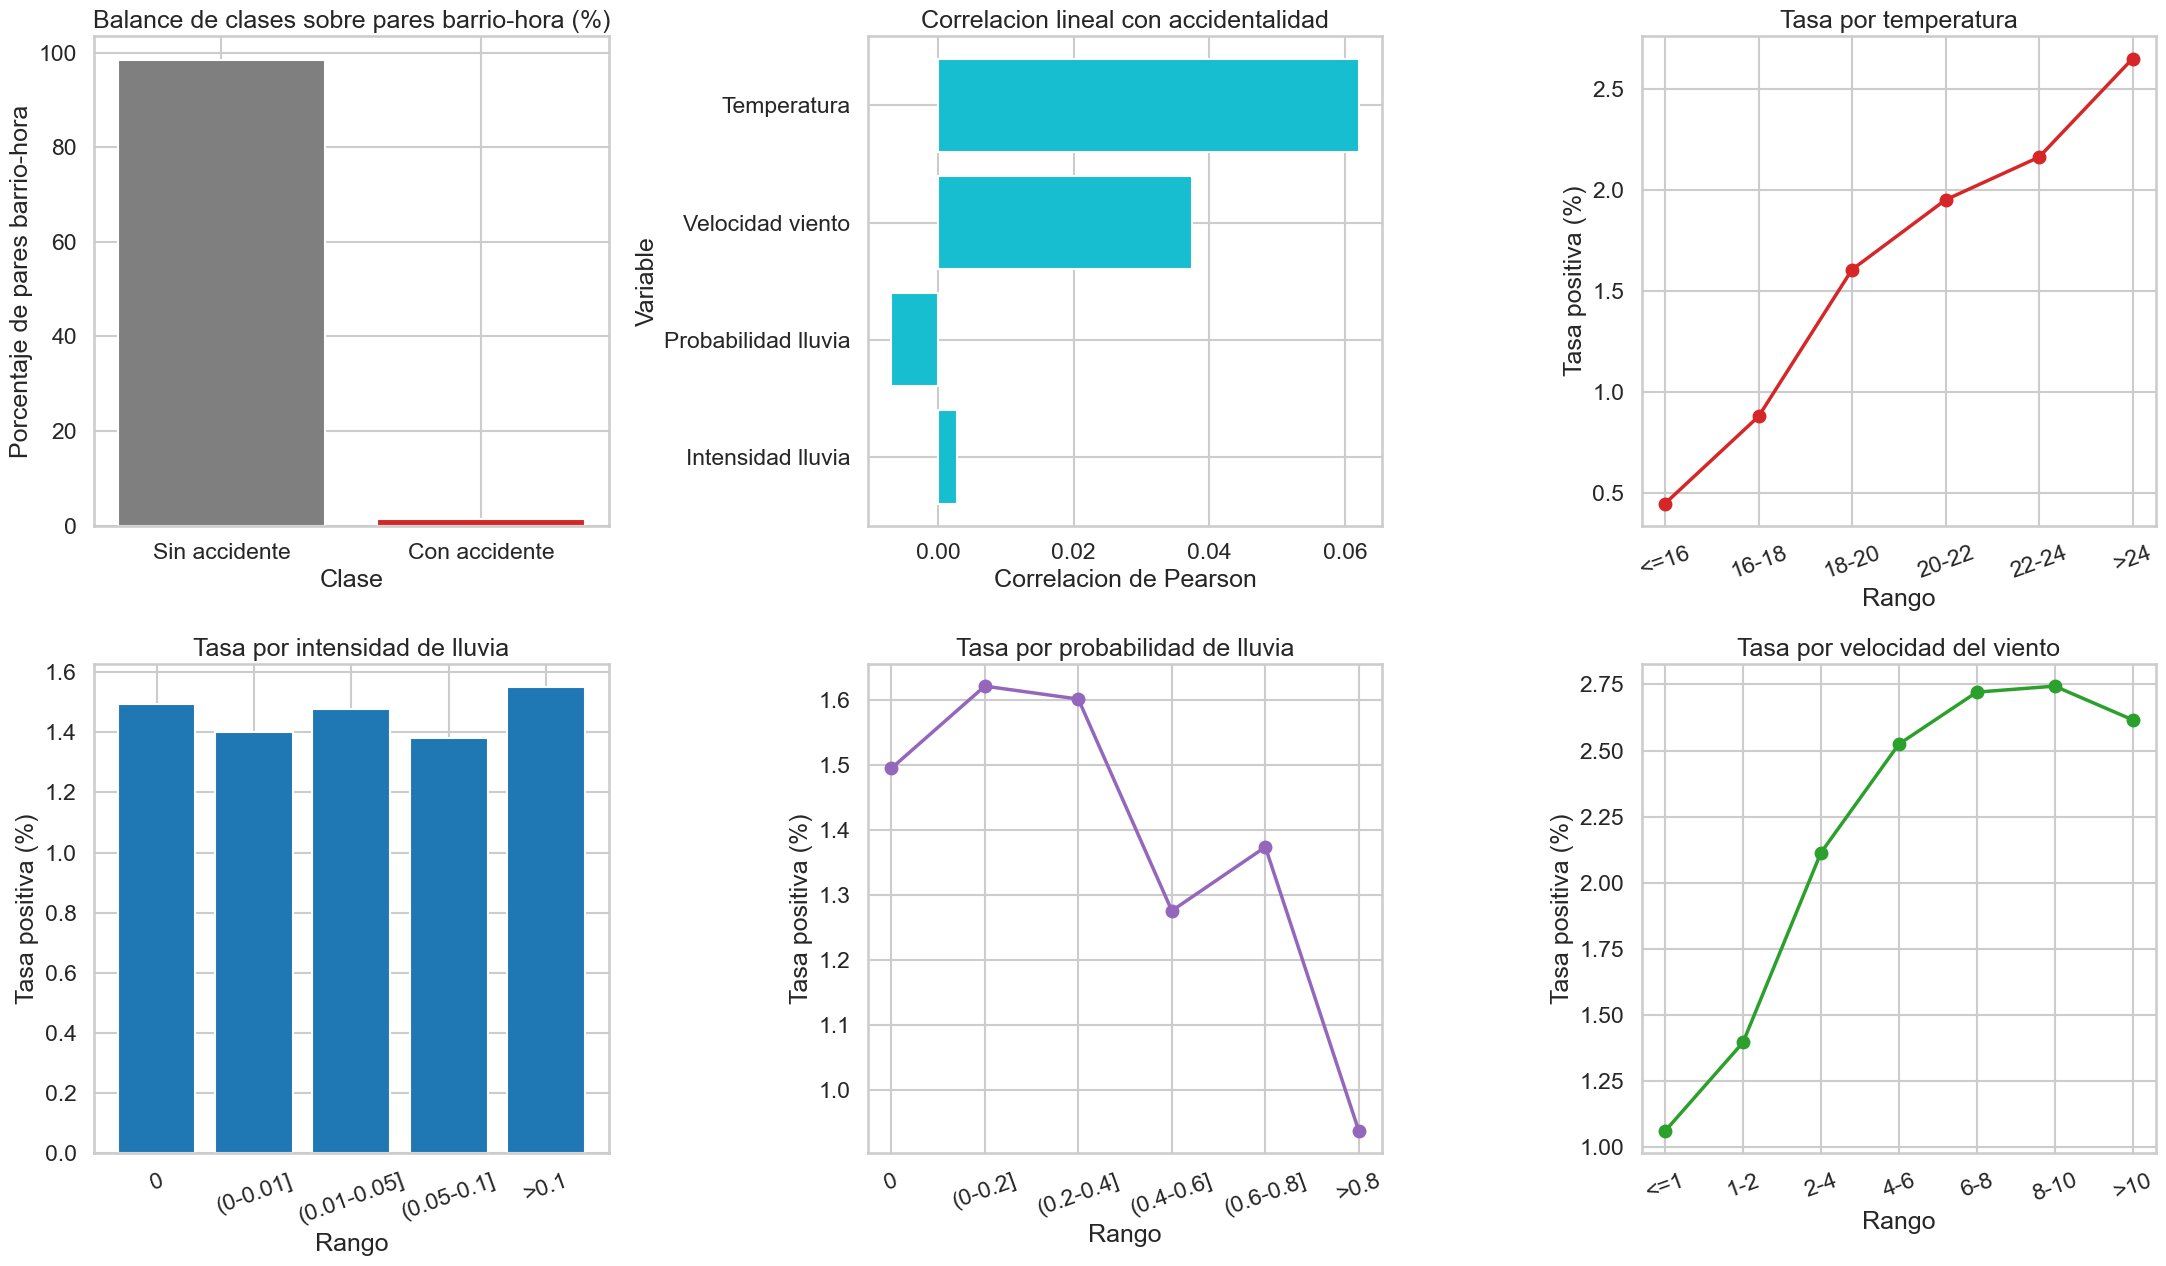

In [16]:

class_balance_df = pd.DataFrame({
    'clase': ['Sin accidente', 'Con accidente'],
    'pct': [(1 - positive_rate) * 100, positive_rate * 100],
    'count': [total_rows - positive_rows, positive_rows],
})

display(Markdown(
    f"""
**Conjunto modelable de pares barrio-hora**

- Total de pares `(barrio, hora)` en `clima`: **{total_rows:,}**.
- Positivos observados dentro de esos pares barrio-hora: **{positive_rows:,}**.
- Tasa positiva global: **{positive_rate * 100:.2f}%**.
"""
))

display(summary_df.round({'mean': 4, 'std': 4, 'min': 4, 'max': 4}))
display(corr_df.round({'correlation': 4}))

fig, axes = plt.subplots(2, 3, figsize=(22, 13))

axes[0, 0].bar(class_balance_df['clase'], class_balance_df['pct'], color=['#7f7f7f', '#d62728'])
axes[0, 0].set_title('Balance de clases sobre pares barrio-hora (%)')
axes[0, 0].set_xlabel('Clase')
axes[0, 0].set_ylabel('Porcentaje de pares barrio-hora')

corr_plot = corr_df.sort_values('correlation', key=lambda s: s.abs(), ascending=True)
axes[0, 1].barh(corr_plot['variable'], corr_plot['correlation'], color='#17becf')
axes[0, 1].set_title('Correlacion lineal con accidentalidad')
axes[0, 1].set_xlabel('Correlacion de Pearson')
axes[0, 1].set_ylabel('Variable')

axes[0, 2].plot(rate_tables['temperature']['bin'], rate_tables['temperature']['rate_pct'], marker='o', linewidth=2.5, color='#d62728')
axes[0, 2].set_title('Tasa por temperatura')
axes[0, 2].set_xlabel('Rango')
axes[0, 2].set_ylabel('Tasa positiva (%)')
axes[0, 2].tick_params(axis='x', rotation=20)

axes[1, 0].bar(rate_tables['precipIntensity']['bin'], rate_tables['precipIntensity']['rate_pct'], color='#1f77b4')
axes[1, 0].set_title('Tasa por intensidad de lluvia')
axes[1, 0].set_xlabel('Rango')
axes[1, 0].set_ylabel('Tasa positiva (%)')
axes[1, 0].tick_params(axis='x', rotation=20)

axes[1, 1].plot(rate_tables['precipProbability']['bin'], rate_tables['precipProbability']['rate_pct'], marker='o', linewidth=2.5, color='#9467bd')
axes[1, 1].set_title('Tasa por probabilidad de lluvia')
axes[1, 1].set_xlabel('Rango')
axes[1, 1].set_ylabel('Tasa positiva (%)')
axes[1, 1].tick_params(axis='x', rotation=20)

axes[1, 2].plot(rate_tables['windSpeed']['bin'], rate_tables['windSpeed']['rate_pct'], marker='o', linewidth=2.5, color='#2ca02c')
axes[1, 2].set_title('Tasa por velocidad del viento')
axes[1, 2].set_xlabel('Rango')
axes[1, 2].set_ylabel('Tasa positiva (%)')
axes[1, 2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()


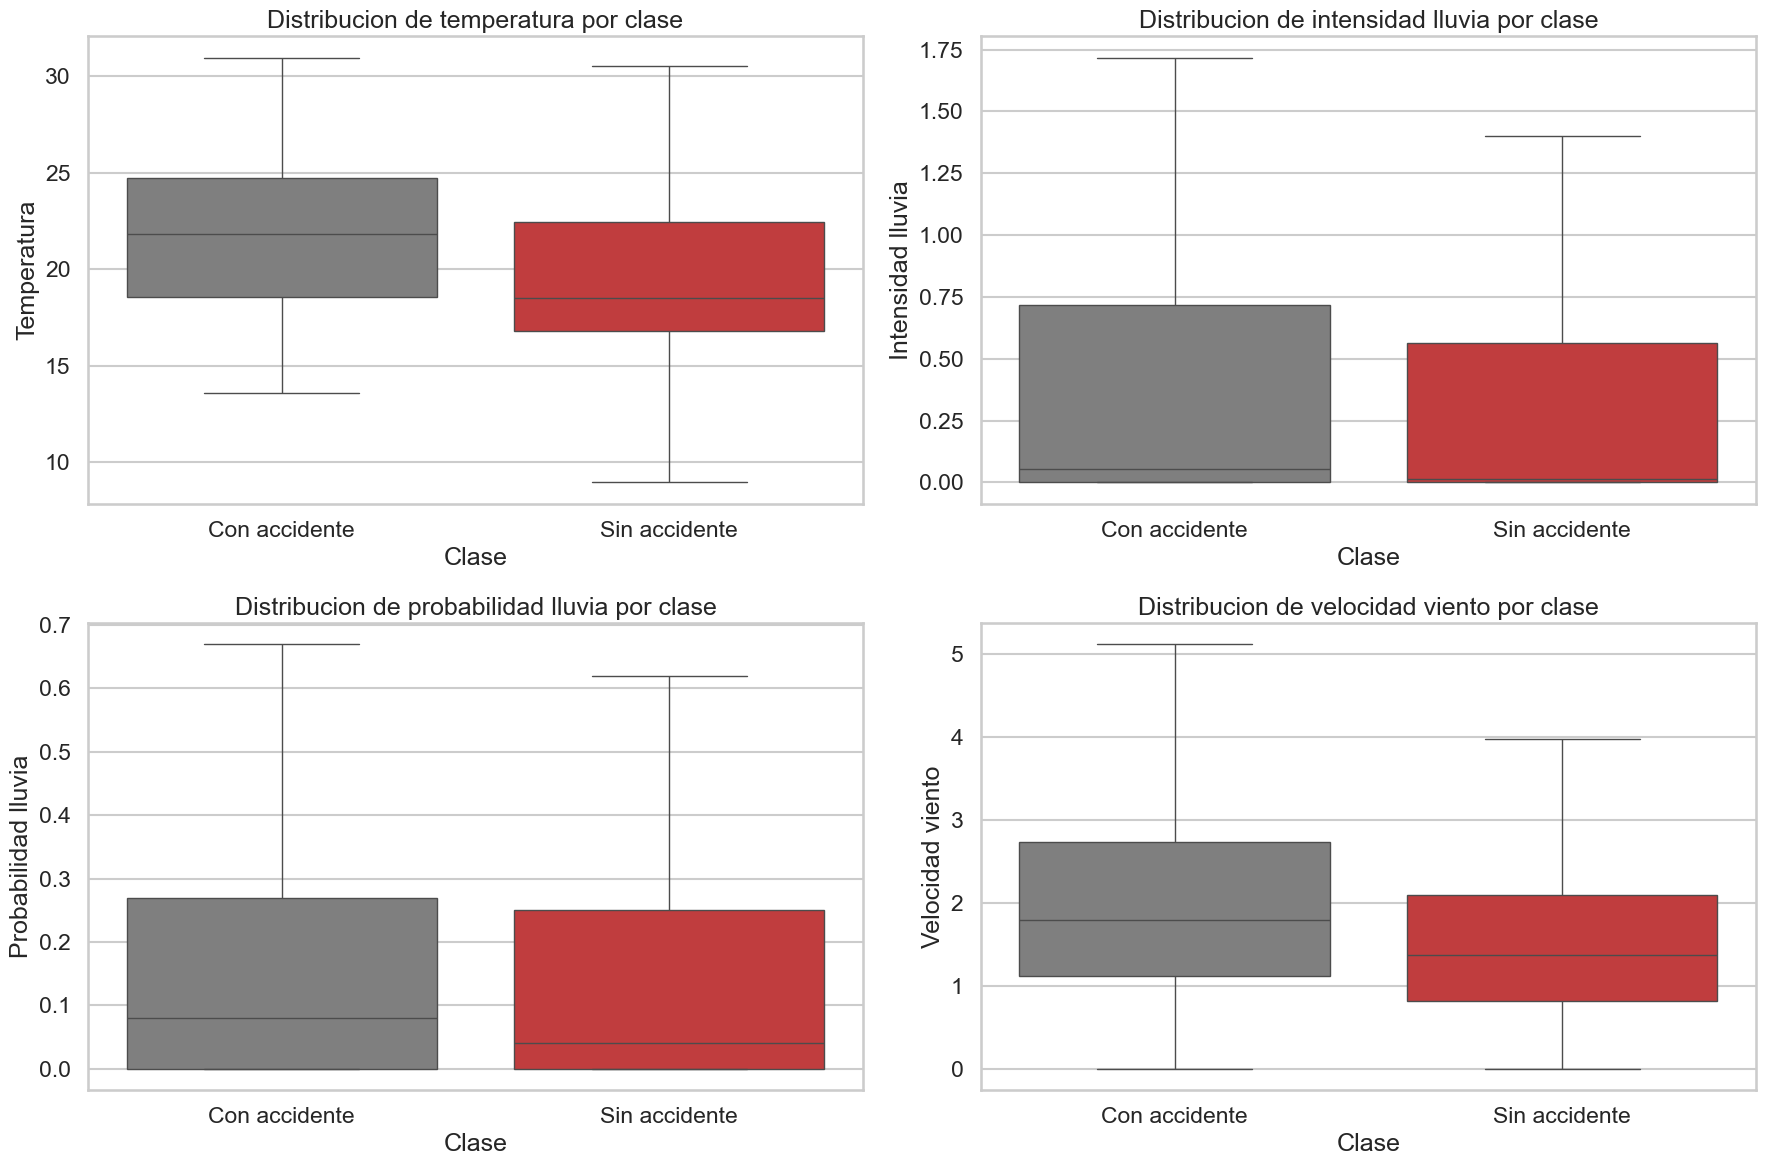

In [17]:

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

for ax, var in zip(axes.flatten(), numeric_vars):
    subset = plot_sample[['accidente_label', var]].dropna()
    sns.boxplot(
        data=subset,
        x='accidente_label',
        y=var,
        ax=ax,
        showfliers=False,
        palette=['#7f7f7f', '#d62728'],
    )
    ax.set_title(f"Distribucion de {CLIMATE_LABELS[var].lower()} por clase")
    ax.set_xlabel('Clase')
    ax.set_ylabel(CLIMATE_LABELS[var])

plt.tight_layout()
plt.show()


Analisis boxplots:
1.Los boxplots muestran desplazamientos entre clases, pero con bastante solapamiento.
2.Ninguna variable climatica por si sola separa bien los accidentes; su valor probablemente esta en la combinacion con tiempo y espacio.

In [18]:

temp_low = float(rate_tables['temperature']['rate_pct'].iloc[0])
temp_high = float(rate_tables['temperature']['rate_pct'].iloc[-1])
wind_low = float(rate_tables['windSpeed']['rate_pct'].iloc[0])
wind_peak = float(rate_tables['windSpeed']['rate_pct'].max())
max_wind_bin = rate_tables['windSpeed'].loc[rate_tables['windSpeed']['rate_pct'].idxmax(), 'bin']
top_corr = corr_df.iloc[0]

summary_text = f"""
## 4. Conclusiones accionables para modelado

- La accidentalidad muestra una estacionalidad temporal clara: el pico aparece a las **{peak_hour:02d}:00**, el dia mas cargado es **{WEEKDAY_LABELS[peak_weekday]}** y el mayor volumen mensual ocurre en **{MONTH_NAMES[peak_month]}**. Esto justifica conservar variables de **hora, dia de la semana y mes**.
- La concentracion espacial es alta a nivel de comunas y moderada a nivel de barrios. El **80%** de los accidentes se alcanza con **{barrios_80} barrios** y **{comunas_80} comunas**. Esto sugiere incluir informacion geografica en varios niveles.
- La tasa espacial agrega una lectura mas justa que el conteo bruto: compara accidentes observados frente a los **pares barrio-hora disponibles** en cada zona. Esto ayuda a distinguir volumen de riesgo relativo.
- Los mapas de densidad, el scatter **conteo vs tasa** y el clustering espacial muestran que no todo el riesgo se explica por un unico patron: aparecen barrios de alto volumen, barrios de alta tasa y agrupaciones geograficas contiguas con comportamiento parecido.
- `DBSCAN` identifica focos espaciales contiguos y zonas de ruido periferico, mientras que `k-means` separa perfiles de barrio usando ubicacion, volumen y patron horario. Esto respalda la idea de crear variables espaciales y temporales agregadas, no solo usar coordenadas crudas.
- El conjunto modelable de pares barrio-hora tiene una tasa positiva de apenas **{positive_rate * 100:.2f}%**, lo que anticipa un problema de **clase desbalanceada** y deja en duda la utilidad de `accuracy` como metrica principal.
- Entre las variables climaticas, la senal lineal mas clara aparece en **{top_corr['variable']}** con una correlacion de **{top_corr['correlation']:.4f}**. Aun asi, las curvas por bins, la visual separada de `precipProbability` y los boxplots sugieren relaciones mas **no lineales** que lineales.
- La tasa positiva sube de **{temp_low:.2f}%** a **{temp_high:.2f}%** entre los extremos de temperatura y aumenta desde **{wind_low:.2f}%** hasta **{wind_peak:.2f}%** en el rango de viento mas critico (**{max_wind_bin}**). Esto favorece modelos capaces de capturar **interacciones** y **umbrales**.
"""

display(Markdown(summary_text))



## 4. Conclusiones accionables para modelado

- La accidentalidad muestra una estacionalidad temporal clara: el pico aparece a las **17:00**, el dia mas cargado es **Viernes** y el mayor volumen mensual ocurre en **Ago**. Esto justifica conservar variables de **hora, dia de la semana y mes**.
- La concentracion espacial es alta a nivel de comunas y moderada a nivel de barrios. El **80%** de los accidentes se alcanza con **120 barrios** y **9 comunas**. Esto sugiere incluir informacion geografica en varios niveles.
- La tasa espacial agrega una lectura mas justa que el conteo bruto: compara accidentes observados frente a los **pares barrio-hora disponibles** en cada zona. Esto ayuda a distinguir volumen de riesgo relativo.
- Los mapas de densidad, el scatter **conteo vs tasa** y el clustering espacial muestran que no todo el riesgo se explica por un unico patron: aparecen barrios de alto volumen, barrios de alta tasa y agrupaciones geograficas contiguas con comportamiento parecido.
- `DBSCAN` identifica focos espaciales contiguos y zonas de ruido periferico, mientras que `k-means` separa perfiles de barrio usando ubicacion, volumen y patron horario. Esto respalda la idea de crear variables espaciales y temporales agregadas, no solo usar coordenadas crudas.
- El conjunto modelable de pares barrio-hora tiene una tasa positiva de apenas **1.51%**, lo que anticipa un problema de **clase desbalanceada** y deja en duda la utilidad de `accuracy` como metrica principal.
- Entre las variables climaticas, la senal lineal mas clara aparece en **Temperatura** con una correlacion de **0.0620**. Aun asi, las curvas por bins, la visual separada de `precipProbability` y los boxplots sugieren relaciones mas **no lineales** que lineales.
- La tasa positiva sube de **0.45%** a **2.65%** entre los extremos de temperatura y aumenta desde **1.06%** hasta **2.74%** en el rango de viento mas critico (**8-10**). Esto favorece modelos capaces de capturar **interacciones** y **umbrales**.


---
## Punto 4.4 – Modelo No Sesgado

### Contenido
1. **Baseline ingenuo** y por qué la *accuracy* no es la métrica adecuada
2. **Estrategias de balanceo**: Class-Weight vs SMOTE
3. **Comparación de tres familias de modelos** con ajuste de hiperparámetros

### 4.4.1 – Baseline Ingenuo y Problema de la Accuracy

Un **clasificador ingenuo** (ZeroR) siempre predice la clase mayoritaria (0 = sin accidente).  
Con un desbalance 98.49% / 1.51%, ese clasificador obtiene ~98.5% de *accuracy* **sin aprender nada**.  
Por eso necesitamos métricas orientadas a la clase minoritaria: **Precision, Recall, F1-score y ROC-AUC**.

In [19]:
import numpy as np
import pandas as pd
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             roc_auc_score, confusion_matrix)

# ── Preparar features y target ──────────────────────────────────────────────
FEATURES = [c for c in df_maestro.columns
            if c not in ['TW', 'BARRIO', 'TARGET']
            and df_maestro[c].dtype in [np.float64, np.int64, np.float32, np.int32]]

print("Features utilizadas:", FEATURES)

# ── PUNTO 4.6: Validación Temporal ──────────────────────────────────────────
# Ordenar cronológicamente para asegurar que no hay mezcla de fechas
df_sorted = df_maestro.sort_values('TW').reset_index(drop=True)

# Ver el rango de fechas disponible
print(f"\nRango de fechas: {df_sorted['TW'].min()} → {df_sorted['TW'].max()}")
print(f"Meses disponibles: {df_sorted['TW'].dt.to_period('M').unique()}")

# Definir el corte temporal: entrenar con los primeros meses, validar con los últimos
# Usamos los primeros 10 meses para entrenamiento y los últimos 2 para prueba
corte = df_sorted['TW'].quantile(0.80)  # 80% del tiempo = entrenamiento
print(f"\nFecha de corte: {corte}")

mask_train = df_sorted['TW'] <= corte
mask_test  = df_sorted['TW'] >  corte

X_all = df_sorted[FEATURES].fillna(0)
y_all = df_sorted['TARGET']

X_train = X_all[mask_train]
y_train = y_all[mask_train]
X_test  = X_all[mask_test]
y_test  = y_all[mask_test]

print(f"\nTrain: {X_train.shape[0]:,} filas | "
      f"Período: {df_sorted.loc[mask_train, 'TW'].min().date()} "
      f"→ {df_sorted.loc[mask_train, 'TW'].max().date()}")
print(f"Test:  {X_test.shape[0]:,} filas  | "
      f"Período: {df_sorted.loc[mask_test, 'TW'].min().date()} "
      f"→ {df_sorted.loc[mask_test, 'TW'].max().date()}")
print(f"\nDesbalanceo en TRAIN — positivos: {y_train.mean()*100:.2f}%")
print(f"Desbalanceo en TEST  — positivos: {y_test.mean()*100:.2f}%")

# ── Baseline: ZeroR (siempre predice clase mayoritaria) ─────────────────────
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

print("\n========== BASELINE INGENUO (ZeroR) ==========")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_dummy):.4f}  ← ¡Engañosamente alta!")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_pred_dummy):.4f}  ← Sin capacidad discriminativa")
print(classification_report(y_test, y_pred_dummy, target_names=['Sin Accidente', 'Con Accidente']))

Features utilizadas: ['precipIntensity', 'precipProbability', 'temperature', 'apparentTemperature', 'dewPoint', 'humidity', 'windSpeed', 'windBearing', 'cloudCover', 'uvIndex', 'visibility', 'Hora_num', 'hora_sin', 'hora_cos']

Rango de fechas: 2017-01-01 00:00:00 → 2019-12-31 23:00:00
Meses disponibles: <PeriodArray>
['2017-01', '2017-02', '2017-03', '2017-04', '2017-05', '2017-06', '2017-07',
 '2017-08', '2017-09', '2017-10', '2017-11', '2017-12', '2018-01', '2018-02',
 '2018-03', '2018-04', '2018-05', '2018-06', '2018-07', '2018-08', '2018-09',
 '2018-10', '2018-11', '2018-12', '2019-01', '2019-02', '2019-03', '2019-04',
 '2019-05', '2019-06', '2019-07', '2019-08', '2019-09', '2019-10', '2019-11',
 '2019-12']
Length: 36, dtype: period[M]

Fecha de corte: 2019-05-22 12:00:00

Train: 6,393,606 filas | Período: 2017-01-01 → 2019-05-22
Test:  1,598,174 filas  | Período: 2019-05-22 → 2019-12-31

Desbalanceo en TRAIN — positivos: 1.47%
Desbalanceo en TEST  — positivos: 1.66%

========== B

### 4.4.2 – Estrategias de Balanceo

| Estrategia | Descripción |
|---|---|
| **class_weight='balanced'** | Penaliza más los errores en la clase minoritaria durante el entrenamiento. No modifica los datos. |
| **SMOTE** | Genera ejemplos sintéticos de la clase minoritaria interpolando entre vecinos reales. Aumenta el training set. |

In [20]:
# Instalar imbalanced-learn si no está disponible
try:
    from imblearn.over_sampling import SMOTE
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'imbalanced-learn',
                    '--break-system-packages', '--quiet'], check=True)
    from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression

# ── Estrategia 1: class_weight='balanced' ───────────────────────────────────
lr_balanced = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_balanced.fit(X_train, y_train)
y_pred_cw = lr_balanced.predict(X_test)

print("===== Estrategia 1: class_weight='balanced' (Regresión Logística) =====")
print(classification_report(y_test, y_pred_cw, target_names=['Sin Accidente', 'Con Accidente']))
print(f"ROC-AUC: {roc_auc_score(y_test, lr_balanced.predict_proba(X_test)[:,1]):.4f}\n")

# ── Estrategia 2: SMOTE ──────────────────────────────────────────────────────
# Usamos una muestra para que SMOTE sea manejable en memoria
SAMPLE = 200_000
X_tr_s = X_train.iloc[:SAMPLE]
y_tr_s = y_train.iloc[:SAMPLE]

smote = SMOTE(random_state=42, k_neighbors=5)
X_res, y_res = smote.fit_resample(X_tr_s, y_tr_s)

print(f"SMOTE: original {y_tr_s.value_counts().to_dict()} → resampleado {dict(zip(*np.unique(y_res, return_counts=True)))}")

lr_smote = LogisticRegression(max_iter=1000, random_state=42)
lr_smote.fit(X_res, y_res)
y_pred_smote = lr_smote.predict(X_test)

print("\n===== Estrategia 2: SMOTE (Regresión Logística) =====")
print(classification_report(y_test, y_pred_smote, target_names=['Sin Accidente', 'Con Accidente']))
print(f"ROC-AUC: {roc_auc_score(y_test, lr_smote.predict_proba(X_test)[:,1]):.4f}")

print("\n→ Comparación: class_weight es más rápido; SMOTE puede mejorar el recall a costa de más falsos positivos.")

===== Estrategia 1: class_weight='balanced' (Regresión Logística) =====
               precision    recall  f1-score   support

Sin Accidente       0.99      0.58      0.73   1571631
Con Accidente       0.03      0.66      0.05     26543

     accuracy                           0.58   1598174
    macro avg       0.51      0.62      0.39   1598174
 weighted avg       0.97      0.58      0.72   1598174

ROC-AUC: 0.6670

SMOTE: original {0: 197401, 1: 2599} → resampleado {0: 197401, 1: 197401}

===== Estrategia 2: SMOTE (Regresión Logística) =====
               precision    recall  f1-score   support

Sin Accidente       0.99      0.73      0.84   1571631
Con Accidente       0.03      0.46      0.05     26543

     accuracy                           0.73   1598174
    macro avg       0.51      0.60      0.45   1598174
 weighted avg       0.97      0.73      0.83   1598174

ROC-AUC: 0.6653

→ Comparación: class_weight es más rápido; SMOTE puede mejorar el recall a costa de más falsos posi

### 4.4.3 – Comparación de Tres Familias de Modelos con Ajuste de Hiperparámetros

Se comparan:
- **Regresión Logística** – modelo lineal, interpretable, rápido
- **Random Forest** – ensamble de árboles, captura no linealidades
- **Gradient Boosting (HistGradientBoosting)** – boosting eficiente para datasets grandes

El ajuste de hiperparámetros se realiza con **RandomizedSearchCV** con validación cruzada estratificada.

In [21]:
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import f1_score
import warnings
warnings.filterwarnings('ignore')

# Usamos una muestra para que el CV sea manejable en tiempo
SAMPLE_CV = 100_000
X_cv = X_train.iloc[:SAMPLE_CV]
y_cv = y_train.iloc[:SAMPLE_CV]

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# ── 1. Regresión Logística ──────────────────────────────────────────────────
param_lr = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['lbfgs', 'saga'],
}
search_lr = RandomizedSearchCV(
    LogisticRegression(class_weight='balanced', max_iter=500, random_state=42),
    param_lr, n_iter=4, cv=cv, scoring='f1', n_jobs=-1, random_state=42)
search_lr.fit(X_cv, y_cv)

# ── 2. Random Forest ────────────────────────────────────────────────────────
param_rf = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None],
    'class_weight': ['balanced'],
}
search_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_rf, n_iter=4, cv=cv, scoring='f1', n_jobs=-1, random_state=42)
search_rf.fit(X_cv, y_cv)

# ── 3. Gradient Boosting ────────────────────────────────────────────────────
param_gb = {
    'max_iter': [100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5],
}
search_gb = RandomizedSearchCV(
    HistGradientBoostingClassifier(class_weight='balanced', random_state=42),
    param_gb, n_iter=4, cv=cv, scoring='f1', n_jobs=-1, random_state=42)
search_gb.fit(X_cv, y_cv)

# ── Evaluación final en Test ────────────────────────────────────────────────
resultados = []
for nombre, search in [('Logística', search_lr), ('Random Forest', search_rf), ('Gradient Boosting', search_gb)]:
    y_pred = search.best_estimator_.predict(X_test)
    y_prob = search.best_estimator_.predict_proba(X_test)[:, 1]
    resultados.append({
        'Modelo': nombre,
        'Mejores Params': str(search.best_params_),
        'F1 (clase 1)': round(f1_score(y_test, y_pred), 4),
        'ROC-AUC': round(roc_auc_score(y_test, y_prob), 4),
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
    })
    print(f"\n{'='*55}")
    print(f"  {nombre} — mejores params: {search.best_params_}")
    print(classification_report(y_test, y_pred, target_names=['Sin Accidente', 'Con Accidente']))

df_resultados = pd.DataFrame(resultados)
print("\n========== RESUMEN COMPARATIVO ==========")
print(df_resultados.to_string(index=False))
print("\n→ Usar F1 y ROC-AUC como criterios de selección, NO la Accuracy.")


  Logística — mejores params: {'solver': 'saga', 'C': 0.01}
               precision    recall  f1-score   support

Sin Accidente       0.99      0.82      0.90   1571631
Con Accidente       0.03      0.29      0.05     26543

     accuracy                           0.81   1598174
    macro avg       0.51      0.56      0.47   1598174
 weighted avg       0.97      0.81      0.88   1598174


  Random Forest — mejores params: {'n_estimators': 50, 'max_depth': 10, 'class_weight': 'balanced'}
               precision    recall  f1-score   support

Sin Accidente       0.98      0.93      0.95   1571631
Con Accidente       0.03      0.13      0.05     26543

     accuracy                           0.91   1598174
    macro avg       0.51      0.53      0.50   1598174
 weighted avg       0.97      0.91      0.94   1598174


  Gradient Boosting — mejores params: {'max_iter': 100, 'max_depth': 5, 'learning_rate': 0.2}
               precision    recall  f1-score   support

Sin Accidente       0